# Paper Figures & Analysis: Connectome-Constrained Spiking Olfactory Pathway

Generates **only** the figures and numerical values that appear in `ccn_publish.tex`, from the 5 trained canonical models (seeds 42-46). Run top-to-bottom.

## Notebook structure

### Part 1: Main paper
- **Setup**: load models + Kreher-2008 data; recompute core metrics (accuracy, sparsity, centroid, decorrelation, APL/Mancini) once via the deterministic engine (`analysis/recompute.py`), plus concentration invariance.
- **Paper values**: a single cell prints every main-text value (accuracy, sparsity, decorrelation, APL suppression, concentration ranges, KC consistency, biological parameters).
- **Figures**: Figure 2 (decorrelation matrices), Figure 3 (concentration invariance), Figure S1 (KC heatmap), Figures S2-S4 (confusion matrix, within-odor consistency, threshold scaling).

### Part 2: Revision experiments
- **R1**: sparsity-loss / energy-constraint forms (no-sparsity, all-neuron, KC-specific).
- **R2**: teacher/student parameter consistency (weighted correlations, scalar CVs).
- **R3**: ablation studies (gap junctions, APL, shuffled connectome -- retrained + post-hoc) -> Figure 4.
- **R4**: LN Picky/Broad fan-out threshold sensitivity (4 splits).
- **R5**: odor-mixture coding (sub-additivity, SVM, Honegger).
- **R6**: task complexity / KC threshold scaling (7/14/28/56 odors).
- **STD**: short-term depression ablation (retrained + post-hoc, incl. gain-control ranges).
- **Revision values**: a single cell prints every reviewer-response value cited in the paper.

### Generated figures
| Paper ref | File | Description |
|-----------|------|-------------|
| Figure 1 | *(manual schematic, not generated)* | Circuit diagram (`1_circuit.jpg`) |
| Figure 2 | `2_core.png` | Decorrelation matrices (OR, PN, KC) |
| Figure 3 | `3_concentration.png` | Concentration invariance |
| Figure 4 | `4_abl.png` | Architecture / ablation bars |
| Figure S1 | `S1_kc_heat.png` | KC activity heatmap |
| Figure S2 | `S2_confusion_matrix.png` | Classification confusion matrix |
| Figure S3 | `S3_within_odor_consistency.png` | Within-odor KC consistency |
| Figure S4 | `S4_threshold_scaling.png` | KC threshold saturation vs task difficulty |

**Prerequisites**: trained models in `results/all_connections_nonad_canonical/`, pre-computed revision results in `results/` subdirectories (or run the "Option A" generation cells).

In [1]:
import sys
from pathlib import Path

# Project root — used for data/model/results paths throughout the notebook.
PKG_ROOT = Path('..').resolve()
if str(PKG_ROOT / 'code') not in sys.path:
    sys.path.insert(0, str(PKG_ROOT / 'code'))

# Find connectome data directory (kreher2008 OR responses + connectivity matrices).
_candidates = [
    PKG_ROOT / 'data',                                    # connectome_emergence/data/
]
DATA_DIR = next((p for p in _candidates if (p / 'kreher2008').is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        f'Cannot find connectome data (kreher2008/). Searched:\n'
        + '\n'.join(f'  {p}' for p in _candidates)
    )

import json
import numpy as np
import torch
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

from analysis import (
    load_models, compute_kc_consistency_per_odor,
    extract_gap_junction_info, run_concentration_invariance,
    analyze_biological_parameters,
)
from analysis.utils import noisy_forward_pass
from core.dataset import load_kreher2008_all_odors, create_dataloaders

print(f'Data dir: {DATA_DIR}')
print('Imports OK')

Data dir: data
Imports OK


## Configuration

In [2]:
# Constants
SEEDS = [42, 43, 44, 45, 46]
N_STEPS = 30
NOISE_STD = 0.3
CONCENTRATIONS = [0.03, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
HILL_EC50 = 1.0
HILL_N = 1
MIN_PARAMS_FOR_CORRELATION = 10
G_SOMA_MIN, G_SOMA_MAX = 1e-9, 20e-9
APL_BOOST = 4.0

# Paths (DATA_DIR already set in imports cell)
MODEL_DIR = PKG_ROOT / 'results' / 'all_connections_nonad_canonical'
OUTPUT_DIR = PKG_ROOT / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Data dir:   {DATA_DIR}')
print(f'Model dir:  {MODEL_DIR}')
print(f'Output dir: {OUTPUT_DIR}')

# --- ensure analysis prerequisites so the figure/recompute cells below run even if
#     executed out of order; cheap re-run (skips anything already loaded). ---
if 'odor_names' not in globals() or 'or_responses' not in globals():
    _trd, _ted, odor_names = load_kreher2008_all_odors(
        DATA_DIR, train_repeats=10, test_repeats=50, noise_std=NOISE_STD, noise_type='multiplicative')
    or_responses = torch.from_numpy(
        pd.read_csv(DATA_DIR / 'kreher2008/orn_responses_normalized.csv', index_col=0).values).float()
if 'models' not in globals():
    models = load_models(DATA_DIR, MODEL_DIR, SEEDS, n_steps=N_STEPS, include_nonad=True)


Data dir:   data
Model dir:  results/all_connections_nonad_canonical
Output dir: figures


In [3]:
# =============================================================================
# PARALLEL TRAINING DISPATCH  (auto-detects this machine's specs)
# The "Option A" generation cells below train MANY independent models. Each run is
# ~single-core (the spiking sim is a sequential per-timestep loop over tiny tensors),
# so we dispatch the runs across the machine's cores. auto_parallel_config() picks the
# worker count from the CPU cores + free RAM it finds; each child is pinned to ONE math
# thread so N workers use ~N cores (not N x ncores). Falls back to safe defaults if
# psutil is missing. Results are bit-identical to sequential (each seed is independently
# seeded; per-seed output files; skip-if-exists preserved).
# =============================================================================
import os, subprocess, time, threading
from concurrent.futures import ThreadPoolExecutor, as_completed

def auto_parallel_config(reserve_cores=1, mem_per_run_gb=1.0, cap=None):
    """Pick a safe number of parallel training workers for THIS machine.
    Bounded by (physical cores - reserve_cores) AND (free RAM / mem_per_run_gb)."""
    try:
        import psutil
        phys  = psutil.cpu_count(logical=False) or os.cpu_count() or 4
        avail = psutil.virtual_memory().available / 1e9   # GB currently free
    except Exception:
        phys, avail = (os.cpu_count() or 4), None
    by_cores = max(1, phys - reserve_cores)               # leave a core for OS/notebook
    by_mem   = int(avail / mem_per_run_gb) if avail else by_cores
    w = max(1, min(by_cores, by_mem))
    return min(w, cap) if cap else w

# Pin each child to a single math thread so stacked runs don't oversubscribe the cores.
_PIN_ENV = {**os.environ, 'OMP_NUM_THREADS': '1', 'MKL_NUM_THREADS': '1',
            'OPENBLAS_NUM_THREADS': '1', 'VECLIB_MAXIMUM_THREADS': '1', 'NUMEXPR_NUM_THREADS': '1'}

def _parse_progress(line, current):
    """Parse a stdout line into a short phase+epoch string, e.g. "teacher ep 150".
    Returns current unchanged if the line carries no progress info."""
    s = line.strip()
    if 'Training teacher' in s:
        return 'teacher: starting'
    if 'Training student' in s:
        return 'student: starting'
    if 'Teacher epoch' in s:
        try:
            ep = s.split('Teacher epoch')[1].split(':')[0].strip()
            return f'teacher ep {ep}'
        except Exception:
            pass
    if 'Ep ' in s:
        try:
            ep = s.split('Ep ')[1].split(':')[0].strip()
            return f'student ep {ep}'
        except Exception:
            pass
    return current

def _cmd_label(cmd):
    """Short human label for a cmd list: prefer --seed / --label flag values."""
    for flag in ('--seed', '--label'):
        if flag in cmd:
            fi = cmd.index(flag)
            if fi + 1 < len(cmd):
                return f'{flag[2:]} {cmd[fi + 1]}'
    return ' '.join(str(x) for x in cmd[-2:])

def run_parallel(cmds, desc='runs', max_workers=None):
    """Run a list of subprocess argv-lists in parallel (bounded pool). Streams stdout
    from each job so the watchdog can report live phase+epoch every 3 min.
    Prints a final done line; returns [(cmd, returncode), ...]. A failing run does
    NOT abort the batch."""
    if not cmds:
        print(f'  ({desc}: nothing to run -- all skipped)'); return []
    mw = max_workers or auto_parallel_config(cap=len(cmds))
    print(f'  {desc}: {len(cmds)} runs on {mw} parallel workers ({os.cpu_count()} cores detected)')
    last_status = {}   # job index -> "teacher ep 150" / "student ep 50" etc.
    completed   = set()
    results     = []
    t0          = time.time()
    stop_evt    = threading.Event()
    def _watchdog():
        while not stop_evt.wait(timeout=180):
            el = time.time() - t0
            in_flight = [i for i in range(len(cmds)) if i not in completed]
            if not in_flight:
                break
            print(f'  [{desc}] +{el/60:.1f}min — {len(completed)}/{len(cmds)} done, {len(in_flight)} running:')
            for i in in_flight[:8]:
                lbl    = _cmd_label(cmds[i])
                status = last_status.get(i, 'starting...')
                print(f'    {lbl}: {status}')
    threading.Thread(target=_watchdog, daemon=True).start()
    def _one(idx, cmd):
        proc = subprocess.Popen(cmd, env=_PIN_ENV, stdout=subprocess.PIPE,
                                stderr=subprocess.PIPE, text=True, bufsize=1)
        for line in proc.stdout:
            last_status[idx] = _parse_progress(line, last_status.get(idx, 'starting...'))
        proc.wait()
        return cmd, proc.returncode, proc.stderr.read()
    with ThreadPoolExecutor(max_workers=mw) as ex:
        futs = {ex.submit(_one, i, c): i for i, c in enumerate(cmds)}
        for fut in as_completed(futs):
            i = futs[fut]
            cmd, rc, stderr = fut.result()
            results.append((cmd, rc))
            completed.add(i)
            if rc != 0:
                print(f'  [{desc}] FAIL {_cmd_label(cmd)}')
                print('    stderr:', (stderr or '')[-600:])
    stop_evt.set()
    nbad = sum(1 for _, rc in results if rc != 0)
    elapsed_total = time.time() - t0
    print(f'  {desc}: done ({len(results)-nbad}/{len(results)} ok) in {elapsed_total:.0f}s')
    return results

def run_parallel_ordered(cmds, desc='runs', max_workers=None, header_of=None):
    """Like run_parallel, but also replays each run's stdout after all finish,
    grouped in submission order. Watchdog prints seed + phase + epoch every 3 min.
    header_of(cmd) -> label shown in watchdog output and replay headers."""
    if not cmds:
        print(f'  ({desc}: nothing to run -- all skipped)'); return []
    mw = max_workers or auto_parallel_config(cap=len(cmds))
    print(f'  {desc}: {len(cmds)} runs on {mw} parallel workers ({os.cpu_count()} cores detected)')
    last_status = {}
    completed   = set()
    outs        = [None] * len(cmds)
    t0          = time.time()
    stop_evt    = threading.Event()
    def _label(i):
        return header_of(cmds[i]) if header_of else _cmd_label(cmds[i])
    def _watchdog():
        while not stop_evt.wait(timeout=180):
            el = time.time() - t0
            in_flight = [i for i in range(len(cmds)) if i not in completed]
            if not in_flight:
                break
            print(f'  [{desc}] +{el/60:.1f}min — {len(completed)}/{len(cmds)} done, {len(in_flight)} running:')
            for i in in_flight[:8]:
                status = last_status.get(i, 'starting...')
                print(f'    {_label(i)}: {status}')
    threading.Thread(target=_watchdog, daemon=True).start()
    def _one(idx, cmd):
        proc = subprocess.Popen(cmd, env=_PIN_ENV, stdout=subprocess.PIPE,
                                stderr=subprocess.PIPE, text=True, bufsize=1)
        lines = []
        for line in proc.stdout:
            lines.append(line)
            last_status[idx] = _parse_progress(line, last_status.get(idx, 'starting...'))
        proc.wait()
        return proc.returncode, lines, proc.stderr.read()
    with ThreadPoolExecutor(max_workers=mw) as ex:
        futs = {ex.submit(_one, i, c): i for i, c in enumerate(cmds)}
        for fut in as_completed(futs):
            i = futs[fut]
            rc, lines, stderr = fut.result()
            outs[i] = (cmds[i], rc, lines, stderr)
            completed.add(i)
    stop_evt.set()
    # One summary line per run: label + final epoch metrics.
    for i, (cmd, rc, lines, stderr) in enumerate(outs):
        hdr = header_of(cmd) if header_of else f'run {i + 1}'
        final = next((l.strip() for l in reversed(lines)
                      if 'Ep ' in l or 'Teacher epoch' in l), None)
        print(f'  {hdr}: {final}' if final else f'  {hdr}: done')
        if rc != 0:
            print(f'  [FAILED rc={rc}] stderr tail:\n', (stderr or '')[-800:])
    nbad = sum(1 for _, rc, _, _ in outs if rc != 0)
    elapsed_total = time.time() - t0
    print(f'  {desc}: done ({len(outs) - nbad}/{len(outs)} ok) in {elapsed_total:.0f}s')
    return [(cmd, rc) for cmd, rc, _, _ in outs]



print(f'Parallel training enabled: up to {auto_parallel_config()} workers on {os.cpu_count()} cores '
      f'(scales with free RAM; pin = 1 thread/run).')


Parallel training enabled: up to 7 workers on 12 cores (scales with free RAM; pin = 1 thread/run).


## Option A: Train models from scratch

Run the cell below to train 5 models (seeds 42-46, 300 epochs each).
Each seed trains its own rate-based teacher first, then distills into the spiking student.
**~30–60 min** on a modern multi-core machine (5 seeds train in parallel — wall-clock equals one seed, not five). Models and `results.json` are saved to `MODEL_DIR`.

Skip this cell if you already have trained models in `results/all_connections_nonad_canonical/`.

In [4]:
# --- TRAIN ALL MODELS IN PARALLEL (skips automatically if pre-trained models exist) ---
# Trains the 5 canonical seeds as 5 independent subprocesses (one per seed), dispatched
# across the machine's cores. Each seed is self-contained -- its own teacher+student under
# its own RNG seed -- so the parallel run is identical to a sequential one. Per-seed output
# is captured and replayed grouped by seed IN ORDER (concurrent execution would otherwise
# interleave the lines). A "Run All" never overwrites saved checkpoints: training is skipped
# once results.json exists. To force a full retrain, delete
# results/all_connections_nonad_canonical/ first (or delete a single results_seedNN.json to
# retrain just that seed).
import sys, subprocess
script = str(PKG_ROOT / 'code' / 'scripts' / 'run_training.py')
CANON_SEEDS = [42, 43, 44, 45, 46]

if (MODEL_DIR / 'results.json').exists():
    print(f'Pre-trained models found in {MODEL_DIR} -- skipping training (delete dir to retrain).')
else:
    # 1) Print the config banner once (not once per seed).
    subprocess.run([sys.executable, script, 'canonical-banner'], env=_PIN_ENV, check=True)
    # 2) Train each missing seed in parallel; output is replayed grouped by seed, in order.
    cmds = [[sys.executable, script, 'canonical', '--seed', str(s)] for s in CANON_SEEDS
            if not (MODEL_DIR / f'results_seed{s}.json').exists()]
    run_parallel_ordered(cmds, desc='canonical training',
                         header_of=lambda c: f"Seed {c[c.index('--seed') + 1]}")
    # 3) Aggregate per-seed results -> results.json + training_curves.png + summary table.
    subprocess.run([sys.executable, script, 'canonical-aggregate'], env=_PIN_ENV, check=True)
    print(f'\nTraining complete. Models saved to {MODEL_DIR}')

# --- Or train directly in-process (sequential, single process) ---
# from scripts.run_training import main as train_main
# train_main()  # no args -> full sequential canonical run (banner + 5 seeds + aggregate)


ALL-CONNECTIONS CANONICAL (5 models)

Seeds: [42, 43, 44, 45, 46]
Epochs: 300
Output: results/all_connections_nonad_canonical
  canonical training: 5 runs on 5 parallel workers (12 cores detected)
  [canonical training] +3.0min — 0/5 done, 5 running:
    Seed 42: student ep 50
    Seed 43: student ep 50
    Seed 44: student ep 50
    Seed 45: student ep 50
    Seed 46: student ep 50
  [canonical training] +6.0min — 0/5 done, 5 running:
    Seed 42: student ep 100
    Seed 43: student ep 100
    Seed 44: student ep 100
    Seed 45: student ep 100
    Seed 46: student ep 100
  [canonical training] +9.0min — 0/5 done, 5 running:
    Seed 42: student ep 200
    Seed 43: student ep 200
    Seed 44: student ep 200
    Seed 45: student ep 200
    Seed 46: student ep 200
  [canonical training] +12.0min — 0/5 done, 5 running:
    Seed 42: student ep 250
    Seed 43: student ep 250
    Seed 44: student ep 250
    Seed 45: student ep 250
    Seed 46: student ep 250
  Seed 42: Ep 300: Train=73.9%,

## Option B: Load pre-trained models

Load the 5 trained model checkpoints and Kreher 2008 odor data.
This is the normal path â€” skip here only if you just ran training above.

In [5]:
# Load Kreher 2008 odor response data
train_dataset, test_dataset, odor_names = load_kreher2008_all_odors(
    DATA_DIR, train_repeats=10, test_repeats=50,  # robust headline eval (1400 samples, seed-independent); was 5
    noise_std=NOISE_STD, noise_type='multiplicative',
)
train_loader, test_loader = create_dataloaders(train_dataset, test_dataset, batch_size=16)
df = pd.read_csv(DATA_DIR / 'kreher2008/orn_responses_normalized.csv', index_col=0)
or_responses = torch.from_numpy(df.values).float()
print(f'Loaded {len(odor_names)} odors, {or_responses.shape[1]} OR types')
print(f'Odors: {odor_names}')

  [connectome build banner suppressed]
Loaded 28 odors, 21 OR types
Odors: ['sfr', 'propanoic acid', 'geranyl acetate', '(1R)-(-)-fenchone', 'E2-hexenal', '2-heptanone', '2,3-butanedione', 'cyclohexanone', 'methyl salicylate', 'benzaldehyde', 'acetophenone', '2-methylphenol', '4-methoxybenzene', '4-allyl-1,2-dimethoxybenzene', '4-methylphenol', '1-butanol', '1-hexanol', '1-octen-3-ol', '1-heptanol', '3-octanol', '1-nonanol', 'ethyl acetate', 'propyl acetate', 'pentyl acetate', 'isopentyl acetate', 'ethyl butyrate', 'octyl acetate', 'carbon dioxide']


In [6]:
# Load trained models
models = load_models(DATA_DIR, MODEL_DIR, SEEDS, n_steps=N_STEPS, include_nonad=True)
print(f'Loaded {len(models)} models')

# Load saved training results (teacher accuracies for the paper-values cell)
with open(MODEL_DIR / 'results.json') as f:
    saved_results = json.load(f)
teacher_accs = saved_results.get('teacher_accs',
    [sd['accuracy'] for sd in saved_results['per_seed']])

  [connectome build banner suppressed]
Loaded 5 models


In [7]:
# Check how many KCs have v_th at the clamped boundary
from core.layers import V_TH_MIN, V_TH_MAX

eps = 1e-6  # tolerance for floating-point boundary check
print(f'v_th clamp range: [{V_TH_MIN*1000:.1f}, {V_TH_MAX*1000:.1f}] mV\n')
print(f'{"Seed":<8} {"At min":<10} {"At max":<10} {"Interior":<10} {"KC min (mV)":<14} {"KC max (mV)":<14} {"KC mean (mV)"}')
print('-' * 80)
for seed, model in zip(SEEDS, models):
    vth = model.kc_layer.kc_neurons.v_th.detach().cpu().numpy()
    n_kc = len(vth)
    at_min = int(np.sum(np.abs(vth - V_TH_MIN) < eps))
    at_max = int(np.sum(np.abs(vth - V_TH_MAX) < eps))
    interior = n_kc - at_min - at_max
    print(f'{seed:<8} {at_min:<10} {at_max:<10} {interior:<10} {vth.min()*1000:<14.2f} {vth.max()*1000:<14.2f} {vth.mean()*1000:.2f}')
print('-' * 80)
# Average across seeds (paper: ~47% of KC thresholds, 65-69/144, pinned at the -30 mV upper bound)
all_at_min = [int(np.sum(np.abs(m.kc_layer.kc_neurons.v_th.detach().cpu().numpy() - V_TH_MIN) < eps)) for m in models]
all_at_max = [int(np.sum(np.abs(m.kc_layer.kc_neurons.v_th.detach().cpu().numpy() - V_TH_MAX) < eps)) for m in models]
print(f'{"Mean":<8} {np.mean(all_at_min):<10.1f} {np.mean(all_at_max):<10.1f} {144-np.mean(all_at_min)-np.mean(all_at_max):<10.1f}')
print(f'\nKC at upper bound (-30 mV): {np.mean(all_at_max):.1f}/144 = {np.mean(all_at_max)/144*100:.1f}%  (per-seed range {min(all_at_max)}-{max(all_at_max)})')

# Total clamped spiking neurons (paper: "All 366 spiking neurons are clamped")
_m0 = models[0]
_n_spk = (len(_m0.antennal_lobe.orn_neurons.v_th) + len(_m0.antennal_lobe.ln_neurons.v_th)
          + len(_m0.antennal_lobe.pn_neurons.v_th) + len(_m0.kc_layer.kc_neurons.v_th))
print(f'Total spiking neurons clamped to biological ranges: {_n_spk}')

v_th clamp range: [-55.0, -30.0] mV

Seed     At min     At max     Interior   KC min (mV)    KC max (mV)    KC mean (mV)
--------------------------------------------------------------------------------
42       0          59         85         -54.98         -30.00         -35.88
43       0          58         86         -54.87         -30.00         -35.85
44       0          63         81         -54.92         -30.00         -36.08
45       1          57         86         -55.00         -30.00         -35.84
46       0          60         84         -54.70         -30.00         -36.07
--------------------------------------------------------------------------------
Mean     0.2        59.4       84.4      

KC at upper bound (-30 mV): 59.4/144 = 41.2%  (per-seed range 57-63)
Total spiking neurons clamped to biological ranges: 366


## Extract circuit properties

In [8]:
# Gap-junction conductances + LN->PN excit/inhib split.
# all_gap_info feeds the paper-values cell below; the LN->PN split is a paper Methods value.
all_gap_info, all_ln_pn_split = [], []
for model in models:
    gap_info, ln_pn_split = extract_gap_junction_info(model)
    all_gap_info.append(gap_info)
    all_ln_pn_split.append(ln_pn_split)

## Compute metrics

In [9]:
# Canonical headline -- recomputed LIVE from the loaded checkpoints via the robust engine.
# analysis/recompute.py pins eval seed 42 + test_repeats=50 + n_trials=50, so the result is
# DETERMINISTIC and reproducible every run (no pre-saved JSON, no run-to-run noise wobble).
# This is the SINGLE source of accuracy, sparsity, centroid, AL/MB/total decorrelation and the
# Mancini ratio -- there are no separate recompute cells, so nothing is computed twice.
from analysis.recompute import recompute_metrics, aggregate
print('Recomputing canonical metrics live from checkpoints (deterministic, eval seed 42)...')
per_seed_metrics = [recompute_metrics(m, DATA_DIR, or_responses) for m in models]
agg = aggregate(per_seed_metrics)
# expose per-seed lists for the downstream table + paper-value cells
accs           = [r['accuracy'] for r in per_seed_metrics]
sps            = [r['sparsity'] for r in per_seed_metrics]
cent_accs      = [r['centroid'] for r in per_seed_metrics]
mancini_ratios = [r['mancini']  for r in per_seed_metrics]
al_decorr      = [r['al_decorr'] for r in per_seed_metrics]      # AL decorr %  (= (1 - PN/OR sim) * 100)
mb_decorr      = [r['mb_decorr'] for r in per_seed_metrics]      # MB decorr %  (= (1 - KC/PN sim) * 100)
total_decorr   = [r['total_decorr'] for r in per_seed_metrics]   # total decorr % (= (1 - KC/OR sim) * 100)
print(f"Test accuracy: {agg['accuracy']['mean']*100:.1f}% +/- {agg['accuracy']['std']*100:.1f}%")
print(f"KC sparsity:   {agg['sparsity']['mean']*100:.1f}% +/- {agg['sparsity']['std']*100:.1f}%")
print(f"Centroid:      {agg['centroid']['mean']*100:.1f}% +/- {agg['centroid']['std']*100:.1f}%")
print(f"Mancini:       {agg['mancini']['mean']:.2f} +/- {agg['mancini']['std']:.2f}")
print(f"Decorr AL/MB/total: {agg['al_decorr']['mean']:.1f}% / {agg['mb_decorr']['mean']:.1f}% / {agg['total_decorr']['mean']:.1f}%")

Recomputing canonical metrics live from checkpoints (deterministic, eval seed 42)...
  [connectome build banner suppressed]
Test accuracy: 70.3% +/- 1.1%
KC sparsity:   12.5% +/- 0.1%
Centroid:      65.9% +/- 0.5%
Mancini:       1.85 +/- 0.05
Decorr AL/MB/total: 4.4% / 35.8% / 39.0%


In [10]:
# Cross-model KC representational consistency (paper: mean pairwise cosine 0.943)
print('Computing KC pattern consistency across models...')
kc_consistency, _ = compute_kc_consistency_per_odor(
    models, or_responses, odor_names, noise_std=NOISE_STD)
print(f'KC pattern consistency (cross-model cosine): {kc_consistency:.3f}')

Computing KC pattern consistency across models...
KC pattern consistency (cross-model cosine): 0.942


In [11]:
# Biological parameters: KC soma conductance g_soma (paper: 14.5 +/- 0.1 nS)
print('Analyzing biological parameters...')
all_bio = [analyze_biological_parameters(m) for m in models]
g_soma_vals = [b['g_soma']['value_nS'] for b in all_bio]
print(f'g_soma: {np.mean(g_soma_vals):.1f} +- {np.std(g_soma_vals):.1f} nS')

Analyzing biological parameters...
g_soma: 14.6 +- 0.1 nS


In [12]:
# Concentration invariance
print('Running concentration invariance (5 models)...')
all_conc_results, all_conc_tests = [], []
for i, (model, seed) in enumerate(zip(models, SEEDS)):
    cr, ct = run_concentration_invariance(
        model, or_responses, seed, CONCENTRATIONS, HILL_EC50, HILL_N,
        noise_std=NOISE_STD)
    all_conc_results.append(cr)
    all_conc_tests.append(ct)
    print(f"  Seed {seed}: SubPN={'P' if ct['sublinear_pn_gain'] else 'F'}, "
          f"FlatKC={'P' if ct['flat_kc_activity'] else 'F'}, "
          f"RobClass={'P' if ct['robust_classification'] else 'F'}, "
          f"Identity={ct['odor_identity_preservation']}")

# Aggregate across models
conc_agg = {}
for c in CONCENTRATIONS:
    cs = str(c)
    conc_agg[cs] = {
        'decoder_accs': [cr[cs]['decoder_acc'] for cr in all_conc_results],
        'kc_centroid_accs': [cr[cs]['kc_centroid_acc'] for cr in all_conc_results],
        'mean_ors': [cr[cs]['mean_or'] for cr in all_conc_results],
        'mean_pns': [cr[cs]['mean_pn'] for cr in all_conc_results],
        'mean_kcs': [cr[cs]['mean_kc'] for cr in all_conc_results],
        'or_sims': [cr[cs]['or_sim'] for cr in all_conc_results],
        'pn_sims': [cr[cs]['pn_sim'] for cr in all_conc_results],
        'kc_sims': [cr[cs]['kc_sim'] for cr in all_conc_results],
    }

Running concentration invariance (5 models)...
  Seed 42: SubPN=P, FlatKC=P, RobClass=P, Identity=PARTIAL
  Seed 43: SubPN=P, FlatKC=P, RobClass=P, Identity=PARTIAL
  Seed 44: SubPN=P, FlatKC=P, RobClass=P, Identity=PARTIAL
  Seed 45: SubPN=P, FlatKC=P, RobClass=P, Identity=PARTIAL
  Seed 46: SubPN=P, FlatKC=P, RobClass=P, Identity=PARTIAL


## Results summary

In [13]:
# Per-seed summary table (all metrics from the deterministic recompute engine, cell above)
print(f"{'Seed':<8} {'Acc':<10} {'Cent':<10} {'Sp':<10} {'AL%':<8} {'MB%':<8} {'Tot%':<8} {'Mancini':<10}")
print('-' * 78)
for i, seed in enumerate(SEEDS):
    print(f'{seed:<8} {accs[i]:<10.1%} {cent_accs[i]:<10.1%} {sps[i]:<10.1%} '
          f'{al_decorr[i]:<8.1f} {mb_decorr[i]:<8.1f} {total_decorr[i]:<8.1f} '
          f'{mancini_ratios[i]:.2f}')
print('-' * 78)
print(f"{'Mean':<8} {np.mean(accs):<10.1%} {np.mean(cent_accs):<10.1%} "
      f"{np.mean(sps):<10.1%} {np.mean(al_decorr):<8.1f} {np.mean(mb_decorr):<8.1f} "
      f"{np.mean(total_decorr):<8.1f} {np.mean(mancini_ratios):.2f}")
print(f"{'Std':<8} {np.std(accs)*100:<10.1f} {np.std(cent_accs)*100:<10.1f} "
      f"{np.std(sps)*100:<10.1f} {np.std(al_decorr):<8.1f} {np.std(mb_decorr):<8.1f} "
      f"{np.std(total_decorr):<8.1f} {np.std(mancini_ratios):.2f}")

Seed     Acc        Cent       Sp         AL%      MB%      Tot%     Mancini   
------------------------------------------------------------------------------
42       70.1%      65.7%      12.7%      4.5      35.3     38.6     1.82
43       71.1%      66.7%      12.4%      4.4      35.2     38.5     1.87
44       70.8%      65.1%      12.5%      6.0      36.7     40.9     1.94
45       68.4%      65.7%      12.5%      2.0      35.1     36.8     1.80
46       71.3%      66.0%      12.4%      5.1      36.8     40.4     1.81
------------------------------------------------------------------------------
Mean     70.3%      65.9%      12.5%      4.4      35.8     39.0     1.85
Std      1.1        0.5        0.1        1.3      0.8      1.5      0.05


## Paper values reference

Every specific numerical value cited in `ccn_publish.tex` is printed below.
If any value changes when models are retrained, the paper text must be updated to match.

In [14]:
# =============================================================================
# PAPER VALUES CITED IN ccn_publish.tex (main text)
# Everything below reuses the single deterministic recompute (cell above), the
# concentration cell, and the parameter-extraction cells -- nothing is recomputed.
# If any value changes on re-run, update the paper text to match.
# =============================================================================

# --- Concentration dynamic ranges + accuracy at specific levels (from the concentration cell) ---
or_ranges = [ct['or_range'] for ct in all_conc_tests]
pn_ranges = [ct['pn_range'] for ct in all_conc_tests]
kc_ranges = [ct['kc_range'] for ct in all_conc_tests]
acc_03 = [cr['0.3']['decoder_acc'] for cr in all_conc_results]
acc_50 = [cr['5.0']['decoder_acc'] for cr in all_conc_results]

# --- KC suppression from the Mancini APL test ---
kc_suppression = (1 - 1 / np.mean(mancini_ratios)) * 100

# --- Near-identical OR response profiles: pairs with cosine > 0.90 across all 28 odors (paper cites "Four" within the ester cluster) ---
_or = or_responses.numpy() if hasattr(or_responses, 'numpy') else np.asarray(or_responses)
_orn = _or / (np.linalg.norm(_or, axis=1, keepdims=True) + 1e-12)
_or_cos = _orn @ _orn.T
_n_or_high = int((_or_cos[np.triu_indices(len(_or_cos), k=1)] > 0.90).sum())

print('=' * 72)
print('Original Submission Paper Values')
print('=' * 72)

print('\n--- Methods: Training Protocol ---')
print(f'  Teacher accuracy:          ~{np.mean(teacher_accs)*100:.0f}%')

print('\n--- Results: Classification & Sparsity ---')
print(f'  Test accuracy:             {np.mean(accs)*100:.1f}% +/- {np.std(accs)*100:.1f}%')
print(f'  Centroid accuracy:         {np.mean(cent_accs)*100:.1f}% +/- {np.std(cent_accs)*100:.1f}%')
print(f'  Chance multiplier:         ~{np.mean(accs)*100/3.6:.0f}x  (of 3.6%)')
print(f'  KC sparsity:               {np.mean(sps)*100:.1f}% +/- {np.std(sps)*100:.1f}%')
print(f'  KCs silent per stimulus:   ~{(1-np.mean(sps))*100:.0f}%')
print(f'  OR pairs with cosine>0.90: {_n_or_high}')
print(f'  Overall accuracy (text):   ~{np.mean(accs)*100:.0f}%')

print('\n--- Results: Decorrelation ---')
print(f'  AL decorrelation:          ~{np.mean(al_decorr):.0f}%')
print(f'  MB decorrelation:          ~{np.mean(mb_decorr):.0f}%')
print(f'  Total decorrelation:       ~{np.mean(total_decorr):.0f}%  (Fig 2: ~39% similarity reduction vs OR)')

print('\n--- Results: APL Inhibition ---')
print(f'  Mancini ratio:             {np.mean(mancini_ratios):.2f} +/- {np.std(mancini_ratios):.2f}')
print(f'  KC suppression:            ~{kc_suppression:.0f}%')

print('\n--- Results: Concentration Invariance ---')
print(f'  PN dynamic range:          {np.mean(pn_ranges):.2f} +/- {np.std(pn_ranges):.2f}x')
print(f'  OR input range:            {np.mean(or_ranges):.2f}x')
print(f'  KC dynamic range:          ~{np.mean(kc_ranges):.2f}x')
print(f'  Accuracy at c=0.3:         {np.mean(acc_03)*100:.0f}%')
print(f'  Accuracy at c=5.0:         {np.mean(acc_50)*100:.0f}%')
print(f'  Accuracy range (c=0.3-5):  {np.mean(acc_03)*100:.0f}--{np.mean(acc_50)*100:.0f}%')

print('\n--- Results: Connectome Dominates (consistency) ---')
print(f'  KC pattern consistency:    {kc_consistency:.3f}')

print('\n--- Results: Parameter Boundaries (biological parameters) ---')
print(f'  g_soma:                    {np.mean(g_soma_vals):.1f} +/- {np.std(g_soma_vals):.1f} nS')
print(f'  Gap junctions:             LN-LN {np.mean([g["ln_ln"] for g in all_gap_info])*1e9:.3f}, '
      f'PN-PN {np.mean([g["pn_pn"] for g in all_gap_info])*1e9:.3f}, '
      f'eLN-PN {np.mean([g["eln_pn"] for g in all_gap_info])*1e9:.3f} nS')

print('\n' + '=' * 72)

Original Submission Paper Values

--- Methods: Training Protocol ---
  Teacher accuracy:          ~93%

--- Results: Classification & Sparsity ---
  Test accuracy:             70.3% +/- 1.1%
  Centroid accuracy:         65.9% +/- 0.5%
  Chance multiplier:         ~20x  (of 3.6%)
  KC sparsity:               12.5% +/- 0.1%
  KCs silent per stimulus:   ~88%
  OR pairs with cosine>0.90: 60
  Overall accuracy (text):   ~70%

--- Results: Decorrelation ---
  AL decorrelation:          ~4%
  MB decorrelation:          ~36%
  Total decorrelation:       ~39%  (Fig 2: ~39% similarity reduction vs OR)

--- Results: APL Inhibition ---
  Mancini ratio:             1.85 +/- 0.05
  KC suppression:            ~46%

--- Results: Concentration Invariance ---
  PN dynamic range:          1.23 +/- 0.02x
  OR input range:            1.75x
  KC dynamic range:          ~1.15x
  Accuracy at c=0.3:         46%
  Accuracy at c=5.0:         78%
  Accuracy range (c=0.3-5):  46--78%

--- Results: Connectome Domin

## Main Figures (paper body)

Figures 2 and 3 as they appear in the paper, plus the Figure S1 KC heatmap. Figure 1 is a manual circuit schematic (not generated). Each cell states the paper figure number, the output filename, and a short caption.

Computing similarity matrices...
Computing KC heatmap...


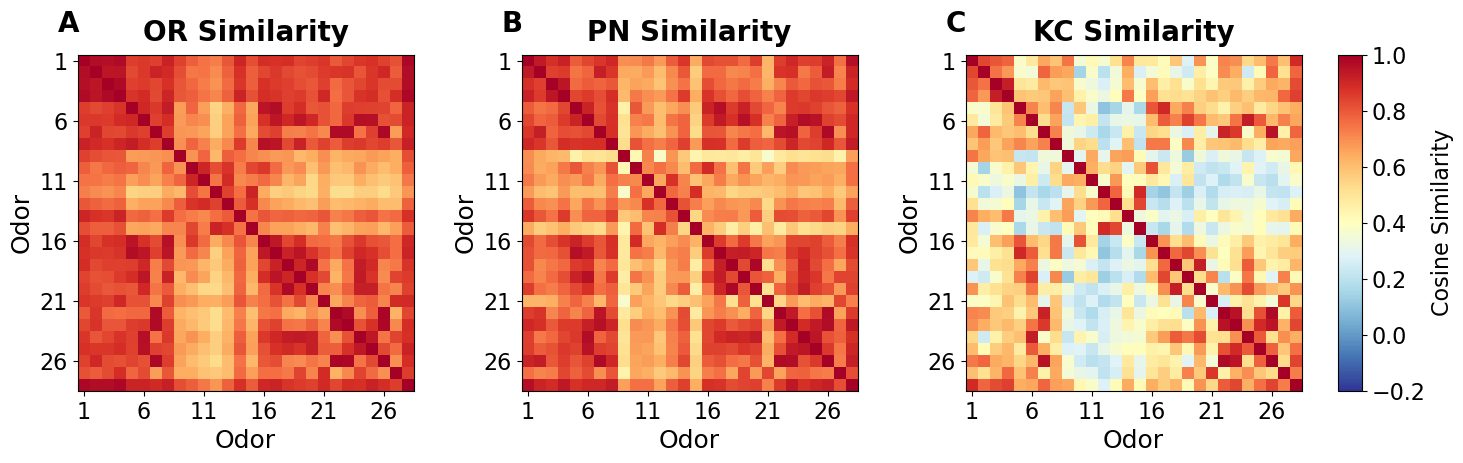

In [15]:
# =============================================================================
# FIGURE 2 — Pairwise similarity matrices (A: OR, B: PN, C: KC)
# File: 2_core.png
# =============================================================================
from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise cosine similarity at each circuit stage (average over 5 models)
print('Computing similarity matrices...')
all_or_sims, all_pn_sims, all_kc_sims = [], [], []
for m in models:
    data = noisy_forward_pass(m, or_responses, n_trials=20, noise_std=NOISE_STD, seed=12345)
    or_patterns = np.array([p.mean(axis=0) for p in data['or_patterns']])
    pn_patterns = np.array([p.mean(axis=0) for p in data['pn_patterns']])
    kc_patterns = np.array([p.mean(axis=0) for p in data['kc_patterns']])
    all_or_sims.append(cosine_similarity(or_patterns))
    all_pn_sims.append(cosine_similarity(pn_patterns))
    all_kc_sims.append(cosine_similarity(kc_patterns))

or_sim = np.mean(all_or_sims, axis=0)
pn_sim = np.mean(all_pn_sims, axis=0)
kc_sim = np.mean(all_kc_sims, axis=0)

# KC activity heatmap from seed-42 model (20 noisy trials)
print('Computing KC heatmap...')
data = noisy_forward_pass(models[0], or_responses, n_trials=20, noise_std=NOISE_STD, seed=12345)
kc_activity = np.array([p.mean(axis=0) for p in data['kc_patterns']])

from analysis import plot_core_figure, plot_kc_heatmap
plot_core_figure(or_sim, pn_sim, kc_sim,
                 output_path=OUTPUT_DIR / '2_core.png', show=True);

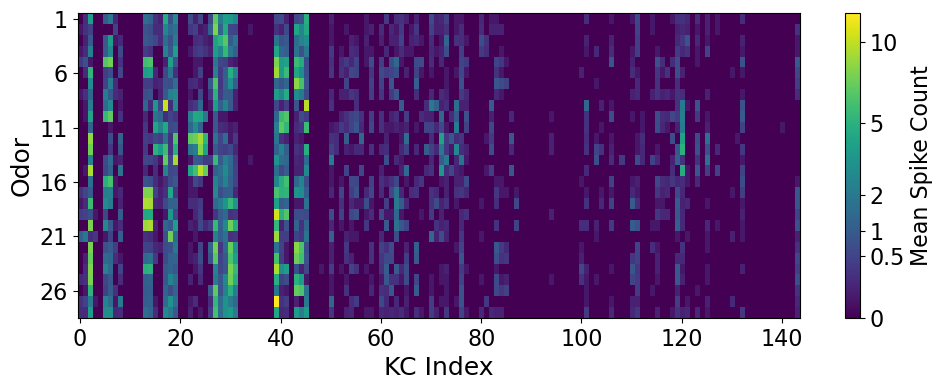

In [16]:
# =============================================================================
# FIGURE S1 — KC Activity Heatmap (paper supplementary; separate from Figure 2)
# File: S1_kc_heat.png
# =============================================================================
plot_kc_heatmap(kc_activity,
                output_path=OUTPUT_DIR / 'S1_kc_heat.png', show=True);

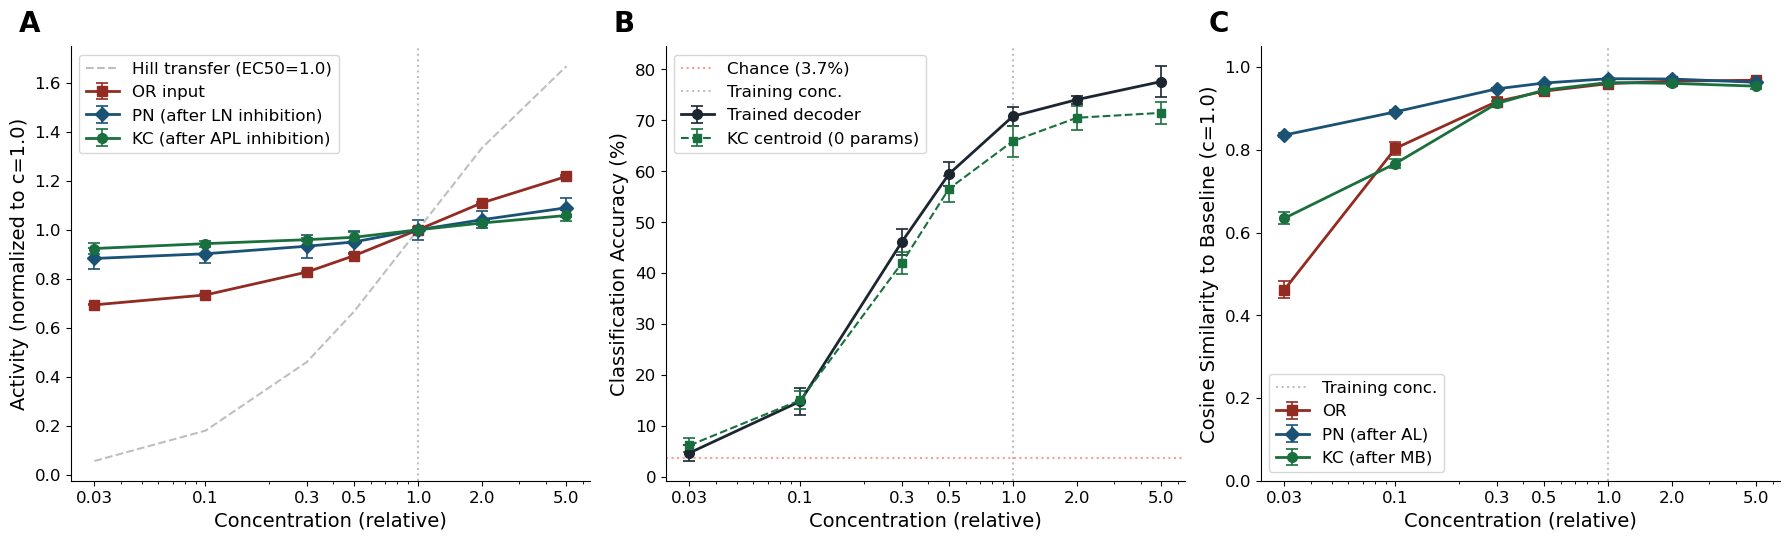

In [17]:
# =============================================================================
# FIGURE 3 â€” Concentration invariance (1x3)
# File: 3_concentration.png
# A: Gain control, B: Classification accuracy, C: Representation similarity
# =============================================================================
from analysis import plot_concentration
plot_concentration(conc_agg, concentrations=CONCENTRATIONS, hill_ec50=HILL_EC50,
                   output_path=OUTPUT_DIR / '3_concentration.png', show=True);

## Revision values reference

### Option A: Run revision experiments from scratch

Skip this section if pre-computed results already exist in `results/`.
Each cell calls the corresponding training script via subprocess.

In [18]:
# R1: Train energy-constraint variants (9 conditions x 5 seeds) -- IN PARALLEL.
# Output: results/energy_only_r1/results_{label}[_seed{s}].json
# (Teachers are trained first and cached; the student conditions then reuse them.)
import sys
SEEDS = [42, 43, 44, 45, 46]
script = str(PKG_ROOT / 'code' / 'scripts' / 'run_training.py')
conditions = [
    ('canonical',          ['--kc-sparsity']),
    ('ce_only',            []),
    ('energy_1',           ['--energy-weight', '1']),
    ('energy_conserv',     ['--energy-weight', '3']),
    ('energy_aggress',     ['--energy-weight', '15']),
    ('energy_50',          ['--energy-weight', '50']),
    ('kc_energy_conserv',  ['--kc-energy-only', '--energy-weight', '3']),
    ('kc_energy_aggress',  ['--kc-energy-only', '--energy-weight', '15']),
    ('kc_energy_50',       ['--kc-energy-only', '--energy-weight', '50']),
]
out_dir = PKG_ROOT / 'results' / 'energy_only_r1'
# 1) Teachers first (parallel) -- cached per seed so the conditions below just load them.
run_parallel([[sys.executable, script, '--train-teacher', '--seed', str(s)] for s in SEEDS],
             desc='R1 teachers')
# 2) Then every student condition in parallel (skip ones whose results already exist).
r1_cmds = []
for seed in SEEDS:
    for label, flags in conditions:
        out = out_dir / (f'results_{label}.json' if seed == 42 else f'results_{label}_seed{seed}.json')
        if out.exists():
            continue
        r1_cmds.append([sys.executable, script, '--label', label, '--seed', str(seed)] + flags)
run_parallel(r1_cmds, desc='R1 energy variants')
print('R1 training complete.')


  R1 teachers: 5 runs on 5 parallel workers (12 cores detected)
  R1 teachers: done (5/5 ok) in 14s
  R1 energy variants: 45 runs on 6 parallel workers (12 cores detected)
  [R1 energy variants] +3.0min — 0/45 done, 45 running:
    seed 42: student ep 50
    seed 42: student ep 50
    seed 42: student ep 50
    seed 42: student ep 50
    seed 42: student ep 50
    seed 42: student ep 50
    seed 42: starting...
    seed 42: starting...
  [R1 energy variants] +6.0min — 0/45 done, 45 running:
    seed 42: student ep 100
    seed 42: student ep 100
    seed 42: student ep 100
    seed 42: student ep 100
    seed 42: student ep 100
    seed 42: student ep 100
    seed 42: starting...
    seed 42: starting...
  [R1 energy variants] +9.0min — 0/45 done, 45 running:
    seed 42: student ep 200
    seed 42: student ep 200
    seed 42: student ep 200
    seed 42: student ep 200
    seed 42: student ep 200
    seed 42: student ep 200
    seed 42: starting...
    seed 42: starting...
  [R1 energy

In [19]:
# R2: Teacher/student parameter consistency analysis (post-hoc, no training)
# Output: results/teacher_consistency_r2/teacher_consistency_results.json
# Runtime: ~5 minutes
import subprocess
script = str(PKG_ROOT / 'code' / 'scripts' / 'run_teacher_consistency.py')
out = PKG_ROOT / 'results' / 'teacher_consistency_r2' / 'teacher_consistency_results.json'
if out.exists():
    print('SKIP R2 (results exist)')
else:
    print("R2: running teacher consistency analysis (~5 min)...")
    t0 = time.time()
    _est = 300
    _ev = threading.Event()
    def _watch():
        while not _ev.wait(timeout=120):
            el = time.time() - t0
            print(f"  [R2] +{el/60:.1f}min — ~{min(99, int(100*el/_est))}% complete")
    threading.Thread(target=_watch, daemon=True).start()
    subprocess.run([sys.executable, script], check=True)
    _ev.set()
    print(f'R2 analysis complete in {time.time()-t0:.0f}s.')

R2: running teacher consistency analysis (~5 min)...
C5: TEACHER PARAMETER CONSISTENCY ANALYSIS

Loading teacher models...
  Loaded teacher seed 42
  Loaded teacher seed 43
  Loaded teacher seed 44
  Loaded teacher seed 45
  Loaded teacher seed 46

Loading student models...
  Loaded student seed 42
  Loaded student seed 43
  Loaded student seed 44
  Loaded student seed 45
  Loaded student seed 46

Available seeds: [42, 43, 44, 45, 46]

1. TEACHER-TEACHER PARAMETER CONSISTENCY
   (High correlation = connectome constrains rate-based solution)

  or_gains:
    Mean pairwise r = 0.9907 +/- 0.0036
    Range: [0.9839, 0.9950]

  decoder_weight:
    Mean pairwise r = 0.7876 +/- 0.0455
    Range: [0.7237, 0.8576]

  decoder_bias:
    Mean pairwise r = 0.9105 +/- 0.0431
    Range: [0.7917, 0.9548]

  kc_threshold:
    Mean pairwise r = 0.5283 +/- 0.1257
    Range: [0.2665, 0.7270]

  apl_gain:
    Mean = 0.903857, CV = 0.0538
    Values: {42: 0.9065046906471252, 43: 0.9809117317199707, 44: 0.92

In [20]:
# R3 + R4 + STD: Ablation studies (retrained + post-hoc + STD + LN threshold) -- IN PARALLEL.
# Output: results/ablations_r1/, results/posthoc_ablations/, results/std_ablation/
import sys, subprocess
SEEDS = [42, 43, 44, 45, 46]
abl_script = str(PKG_ROOT / 'code' / 'scripts' / 'run_ablation.py')
abl_dir = PKG_ROOT / 'results' / 'ablations_r1'

# 1) Teachers first (parallel, cached per seed). The no-gap/no-apl conditions reuse them;
#    the shuffle condition trains its own shuffled teacher internally.
run_parallel([[sys.executable, abl_script, '--train-teacher', '--seed', str(s)] for s in SEEDS],
             desc='ablation teachers')

# 2) R3 retrained ablations -- parallel (skip existing).
r3_conditions = [('r3i_no_gap',      ['--no-gap', '--kc-sparsity']),
                 ('r3ii_no_apl_fix', ['--no-apl', '--kc-sparsity']),
                 ('r3iii_shuffle',   ['--shuffle', '--kc-sparsity'])]
r3_cmds = [[sys.executable, abl_script, '--label', f'{label}_s{seed}', '--seed', str(seed)] + flags
           for seed in SEEDS for label, flags in r3_conditions
           if not (abl_dir / f'results_{label}_s{seed}.json').exists()]
run_parallel(r3_cmds, desc='R3 retrained ablations')

# 3) R3 post-hoc (single call; loops conditions internally).
ph_dir = PKG_ROOT / 'results' / 'posthoc_ablations'
if (ph_dir / 'results_no_gap_posthoc.json').exists() and (ph_dir / 'results_no_apl_posthoc.json').exists():
    print('  SKIP R3 post-hoc (results exist)')
else:
    subprocess.run([sys.executable, abl_script, 'posthoc'], env=_PIN_ENV, check=True)

# 4) R4 LN-threshold sensitivity -- parallel (skip existing).
r4_quantiles = [('r4_fix_q0.20', '0.20'), ('r4_fix_q0.417', '0.417'), ('r4_fix_q0.50', '0.50')]
r4_cmds = [[sys.executable, abl_script, '--kc-sparsity', '--ln-quantile', q,
            '--label', f'{label}_s{seed}', '--seed', str(seed)]
           for seed in SEEDS for label, q in r4_quantiles
           if not (abl_dir / f'results_{label}_s{seed}.json').exists()]
run_parallel(r4_cmds, desc='R4 LN-threshold sweep')

# 5) STD ablation (single call; trains both conditions internally).
std_dir = PKG_ROOT / 'results' / 'std_ablation'
if (std_dir / 'no_std_train' / 'results.json').exists() and (std_dir / 'posthoc_std_off' / 'results.json').exists():
    print('  SKIP STD (results exist)')
else:
    subprocess.run([sys.executable, abl_script, 'std', '--condition', 'both'], env=_PIN_ENV, check=True)
print('R3 + R4 + STD complete.')


  ablation teachers: 5 runs on 4 parallel workers (12 cores detected)
  ablation teachers: done (5/5 ok) in 6s
  (R3 retrained ablations: nothing to run -- all skipped)
Kreher 2008 data: 28 odors x 21 OR types

SEED 42

--- Post-hoc: Remove gap junctions (seed 42) ---
  [connectome build banner suppressed]
  Post-hoc: gap junctions zeroed (all conductances -> ~0)
  Acc:     linear=66.4%, centroid=68.2%
  Sparse:  ORN=61.4%, LN=35.5%, PN=32.7%, KC=13.6%
  Decorr:  AL=-0.5%, MB=35.0%
  Mancini: 1.88
  FlatKC:  True, KC range: 1.12x

--- Post-hoc: Disable APL (seed 42) ---
  [connectome build banner suppressed]
  Post-hoc: APL disabled (gain=-100, softplus=3.78e-44)
  Acc:     linear=64.3%, centroid=65.0%
  Sparse:  ORN=62.2%, LN=33.5%, PN=28.7%, KC=30.4%
  Decorr:  AL=5.0%, MB=29.5%
  Mancini: SKIP
  FlatKC:  False, KC range: 1.21x

SEED 43

--- Post-hoc: Remove gap junctions (seed 43) ---
  [connectome build banner suppressed]
  Post-hoc: gap junctions zeroed (all conductances -> ~0)
  

In [21]:
# R5: Odor mixture analysis (post-hoc on canonical models, no training)
# Output: results/odor_mixtures_r5/mixture_summary.json, honegger_metric.json
# Runtime: ~30 minutes (mixture) + ~10 minutes (Honegger)
import subprocess
mix_dir = PKG_ROOT / 'results' / 'odor_mixtures_r5'

# Mixture summary
if (mix_dir / 'mixture_summary.json').exists():
    print('SKIP R5 mixtures (results exist)')
else:
    print("R5: running odor mixture analysis (~30 min)...")
    t0_mix = time.time()
    _est_mix = 1800
    _ev_mix = threading.Event()
    def _watch_mix():
        while not _ev_mix.wait(timeout=180):
            el = time.time() - t0_mix
            print(f"  [R5 mixtures] +{el/60:.1f}min — ~{min(99, int(100*el/_est_mix))}% complete")
    threading.Thread(target=_watch_mix, daemon=True).start()
    subprocess.run([sys.executable, str(PKG_ROOT / 'code' / 'scripts' / 'run_odor_mixtures.py')], check=True)
    _ev_mix.set()
    print(f'R5 mixture analysis complete in {time.time()-t0_mix:.0f}s.')

# Honegger sub-additivity metric
if (mix_dir / 'honegger_metric.json').exists():
    print('SKIP R5 Honegger (results exist)')
else:
    print("R5: running Honegger sub-additivity metric (~10 min)...")
    t0_hon = time.time()
    _est_hon = 600
    _ev_hon = threading.Event()
    def _watch_hon():
        while not _ev_hon.wait(timeout=180):
            el = time.time() - t0_hon
            print(f"  [R5 Honegger] +{el/60:.1f}min — ~{min(99, int(100*el/_est_hon))}% complete")
    threading.Thread(target=_watch_hon, daemon=True).start()
    subprocess.run([sys.executable, str(PKG_ROOT / 'code' / 'scripts' / 'run_odor_mixtures.py'), '--honegger'], check=True)
    _ev_hon.set()
    print(f'R5 Honegger metric complete in {time.time()-t0_hon:.0f}s.')

R5: running odor mixture analysis (~30 min)...
Loaded 28 odors x 21 OR types

SEED 42: MIXTURE ANALYSIS
  [connectome build banner suppressed]

  Getting KC codes for 28 individual odors...
  Generating 351 2-odor mixture codes...
  Generating 50 3-odor mixture codes...
  Testing linear separability...
  Saved: results/odor_mixtures_r5/mixture_results_seed42.json

  --- Seed 42 Summary ---
  2-odor mix sim to components:   0.811 ± 0.057
  2-odor mix sim to linear pred:  0.946 ± 0.024
  2-odor suppression ratio:       1.245 ± 0.100
  3-odor suppression ratio:       1.417 ± 0.104
  Individual SVM accuracy:        64.1%
  Mixture vs individual SVM:      74.7%
  Inter-mixture SVM:              43.5%

SEED 43: MIXTURE ANALYSIS
  [connectome build banner suppressed]

  Getting KC codes for 28 individual odors...
  Generating 351 2-odor mixture codes...
  Generating 50 3-odor mixture codes...
  Testing linear separability...
  Saved: results/odor_mixtures_r5/mixture_results_seed43.json

  ---

In [22]:
# R6: Task complexity -- train models with different odor counts -- IN PARALLEL.
# Output: results/task_complexity_r6/results_r6_n{7,14,56}_s{42-46}.json
import sys
script = str(PKG_ROOT / 'code' / 'scripts' / 'run_task_complexity.py')
r6_dir = PKG_ROOT / 'results' / 'task_complexity_r6'
SEEDS = [42, 43, 44, 45, 46]
r6_cmds = [[sys.executable, script, '--n-odors', str(n_od), '--seed', str(seed)]
           for n_od in [7, 14, 56] for seed in SEEDS
           if not (r6_dir / f'results_r6_n{n_od}_s{seed}.json').exists()]
run_parallel(r6_cmds, desc='R6 task complexity')
print('R6 task complexity complete.')


  R6 task complexity: 15 runs on 8 parallel workers (12 cores detected)
  [R6 task complexity] +64.9min — 0/15 done, 15 running:
    seed 42: student ep 150
    seed 43: student ep 150
    seed 44: student ep 150
    seed 45: student ep 150
    seed 46: student ep 150
    seed 42: student ep 50
    seed 43: student ep 50
    seed 44: student ep 50
  [R6 task complexity] +84.0min — 5/15 done, 10 running:
    seed 42: student ep 200
    seed 43: student ep 200
    seed 44: student ep 200
    seed 45: teacher: starting
    seed 46: teacher: starting
    seed 42: teacher: starting
    seed 43: teacher: starting
    seed 44: teacher: starting
  [R6 task complexity] +87.0min — 6/15 done, 9 running:
    seed 42: student ep 300
    seed 44: student ep 300
    seed 45: student ep 100
    seed 46: student ep 100
    seed 42: teacher: starting
    seed 43: teacher: starting
    seed 44: teacher: starting
    seed 45: starting...
  [R6 task complexity] +90.0min — 8/15 done, 7 running:
    seed 45:

### Option B: Load pre-computed revision results

Run this section to load existing results from `results/`. Skip Option A if results already exist.

## Supporting Figures

Paper supplementary figures, generated live from the 5 canonical models:
- **Figure S1** — KC activity heatmap (`S1_kc_heat.png`), generated above in the *Main Figures* section.
- **Figure S2** — classification confusion matrix (`S2_confusion_matrix.png`).
- **Figure S3** — within-odor KC representational consistency across noise realizations (`S3_within_odor_consistency.png`).
- **Figure S4** — KC spike-threshold saturation vs task difficulty (`S4_threshold_scaling.png`).

  [connectome build banner suppressed]


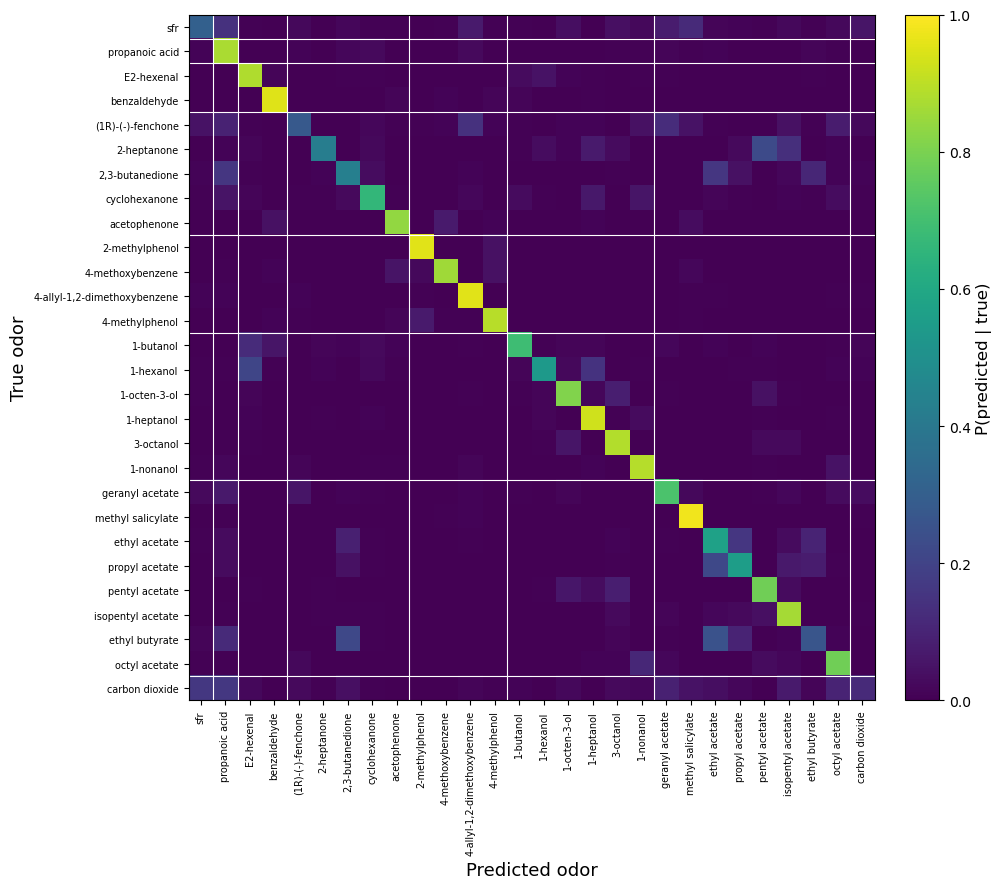

S2 mean diagonal (per-odor accuracy) = 0.703


In [23]:
# =============================================================================
# FIGURE S2 — Classification confusion matrix
# File: S2_confusion_matrix.png
# Mean over the 5 models (50 noisy trials/odor). The same loop also computes
# within-odor KC consistency (_within_odor_cons), consumed by Figure S2 below.
# =============================================================================
# --- prerequisite guard: self-load data + models if those cells weren't run this session ---
# (requires the imports + constants cells above to have run: DATA_DIR, torch, load_* , NOISE_STD, etc.)
if 'odor_names' not in globals() or 'or_responses' not in globals():
    _td, _ted, odor_names = load_kreher2008_all_odors(
        DATA_DIR, train_repeats=10, test_repeats=50, noise_std=NOISE_STD, noise_type='multiplicative')
    or_responses = torch.from_numpy(
        pd.read_csv(DATA_DIR / 'kreher2008/orn_responses_normalized.csv', index_col=0).values).float()
if 'models' not in globals():
    models = load_models(DATA_DIR, MODEL_DIR, SEEDS, n_steps=N_STEPS, include_nonad=True)

_S2_N_TRIALS = 50
n_odors = len(odor_names)
_conf = np.zeros((n_odors, n_odors))
_within_odor_cons = np.full((len(models), n_odors), np.nan)
for _m, _model in enumerate(models):
    _d = noisy_forward_pass(_model, or_responses, n_trials=_S2_N_TRIALS,
                            noise_std=NOISE_STD, seed=42 + _m)
    for _o in range(n_odors):
        for _p in np.asarray(_d['logits'][_o]).argmax(axis=1):
            _conf[_o, int(_p)] += 1
        _K = np.asarray(_d['kc_patterns'][_o], dtype=float)
        _nrm = np.linalg.norm(_K, axis=1); _ok = _nrm > 1e-9
        if _ok.sum() < 2:
            _within_odor_cons[_m, _o] = 0.0
        else:
            _Kn = _K[_ok] / _nrm[_ok][:, None]; _S = _Kn @ _Kn.T
            _iu = np.triu_indices(_S.shape[0], k=1)
            _within_odor_cons[_m, _o] = float(_S[_iu].mean())

_conf_norm = _conf / _conf.sum(axis=1, keepdims=True)
_families = [('sfr', [0]), ('acid', [1]), ('aldehyde', [4, 9]),
             ('ketone', [3, 5, 6, 7, 10]), ('aromatic', [11, 12, 13, 14]),
             ('alcohol', [15, 16, 17, 18, 19, 20]),
             ('ester', [2, 8, 21, 22, 23, 24, 25, 26]), ('CO2', [27])]
_order = [i for _, idxs in _families for i in idxs]
_labels = [odor_names[i] for i in _order]
_conf_ord = _conf_norm[np.ix_(_order, _order)]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(_conf_ord, cmap='viridis', vmin=0, vmax=1, aspect='equal', interpolation='nearest')
ax.set_xticks(range(n_odors)); ax.set_xticklabels(_labels, rotation=90, fontsize=7)
ax.set_yticks(range(n_odors)); ax.set_yticklabels(_labels, fontsize=7)
ax.set_xlabel('Predicted odor', fontsize=13); ax.set_ylabel('True odor', fontsize=13)
_b = 0
for _, _idxs in _families[:-1]:
    _b += len(_idxs)
    ax.axhline(_b - 0.5, color='white', lw=0.8); ax.axvline(_b - 0.5, color='white', lw=0.8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('P(predicted | true)', fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'S2_confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'S2 mean diagonal (per-odor accuracy) = {np.diag(_conf_norm).mean():.3f}')

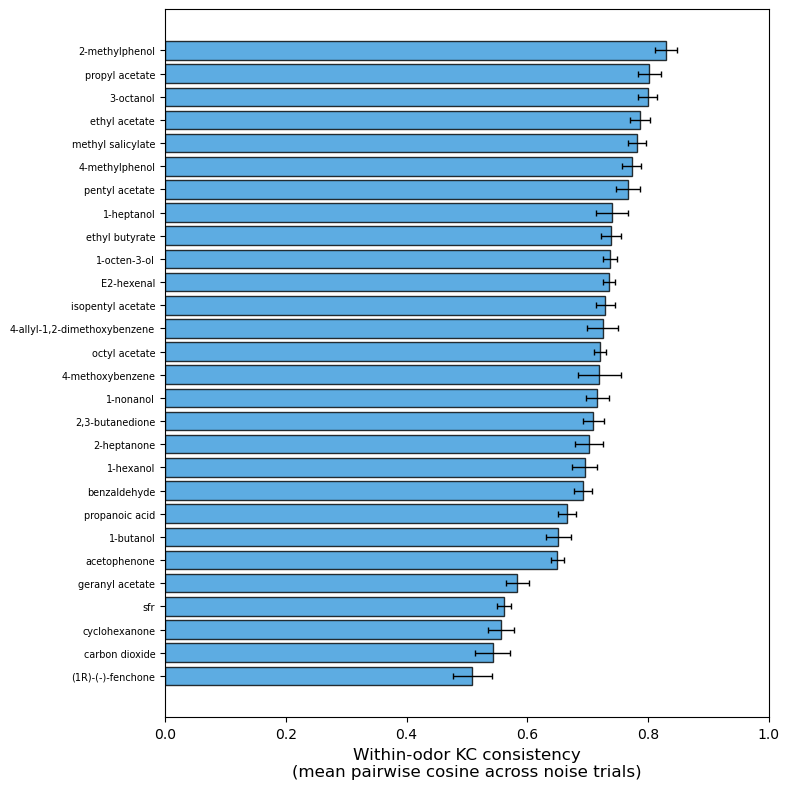

S3 overall mean within-odor consistency = 0.701


In [24]:
# =============================================================================
# FIGURE S3 — Within-odor KC representational consistency across noise realizations
# File: S3_within_odor_consistency.png
# Uses _within_odor_cons computed in the Figure S2 cell above (run that first).
# =============================================================================
_mean_c = np.nanmean(_within_odor_cons, axis=0)
_std_c = np.nanstd(_within_odor_cons, axis=0)
_ordc = np.argsort(_mean_c)[::-1]
_y = np.arange(len(odor_names))

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(_y, _mean_c[_ordc], xerr=_std_c[_ordc], color='#3498db', edgecolor='black',
        alpha=0.8, capsize=2, error_kw={'linewidth': 1})           # D1-sparsity bar style
ax.set_yticks(_y); ax.set_yticklabels([odor_names[i] for i in _ordc], fontsize=7)
ax.set_xlabel('Within-odor KC consistency\n(mean pairwise cosine across noise trials)', fontsize=12)
ax.set_xlim(0, 1)
ax.invert_yaxis()                                     # highest consistency at top
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'S3_within_odor_consistency.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'S3 overall mean within-odor consistency = {np.nanmean(_mean_c):.3f}')

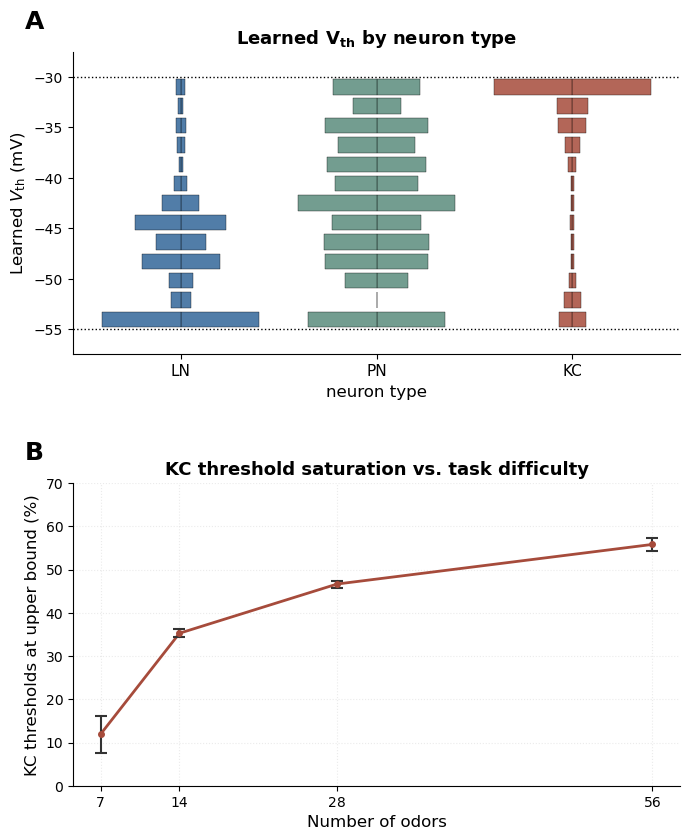

Saved S4_threshold_scaling.png


In [25]:
# =============================================================================
# FIGURE S4 — Learned thresholds & KC saturation vs task difficulty  ->  S4_threshold_scaling.png
# (A) Learned v_th by population (LN/PN/KC) across the 5 canonical models vs the
#     [-55, -30] mV clamp.  (B) Fraction of KC thresholds pinned at the -30 mV upper
#     bound vs odor count (read from the R6 checkpoints; parameter-based, no forward passes).
# A is stacked on top of B. Self-contained; uses `models` (Load Models cell).
# =============================================================================
from analysis.recompute import kc_upper_bound_fraction
from core.layers import V_TH_MIN, V_TH_MAX
_s4_r6_dir = PKG_ROOT / 'results' / 'task_complexity_r6'
_s4_scaling = {}
for _n in [7, 14, 28, 56]:
    _cks = ([MODEL_DIR / f'model_seed{_s}.pt' for _s in SEEDS] if _n == 28
            else [_s4_r6_dir / f'model_r6_n{_n}_s{_s}.pt' for _s in SEEDS])
    _fr = [kc_upper_bound_fraction(_ck) for _ck in _cks if _ck.exists()]
    _s4_scaling[_n] = (float(np.mean(_fr)), float(np.std(_fr)))

_s4_pops = [('LN', lambda m: m.antennal_lobe.ln_neurons),
            ('PN', lambda m: m.antennal_lobe.pn_neurons),
            ('KC', lambda m: m.kc_layer.kc_neurons)]
_s4_vth = []
for _nm, _get in _s4_pops:
    _vv = []
    for _m in models:
        _vv.extend((_get(_m).v_th.detach().cpu().numpy() * 1000).tolist())
    _s4_vth.append(_vv)

fig, (axA, axB) = plt.subplots(2, 1, figsize=(7, 8.5))   # A stacked on top of B

# Panel A (top): learned v_th by population.
# horizontal histograms per neuron type; bins strictly inside the [-55,-30] clamp so bars stay
# clearly within (not on) the bound lines
_hbins = np.linspace(V_TH_MIN * 1000, V_TH_MAX * 1000, 14)
_hcent = (_hbins[:-1] + _hbins[1:]) / 2
_hh = (_hbins[1] - _hbins[0]) * 0.8
for _i, (_col, _vv) in enumerate(zip(['#336699', '#5a8c7d', '#a64b3b'], _s4_vth)):
    _counts, _ = np.histogram(_vv, bins=_hbins)
    _w = _counts / _counts.max() * 0.4
    axA.barh(_hcent, _w, left=_i + 1, height=_hh, color=_col, alpha=0.85, edgecolor='black', linewidth=0.3)
    axA.barh(_hcent, -_w, left=_i + 1, height=_hh, color=_col, alpha=0.85, edgecolor='black', linewidth=0.3)
axA.axhline(V_TH_MAX * 1000, ls=':', color='black', lw=1)
axA.axhline(V_TH_MIN * 1000, ls=':', color='black', lw=1)
axA.set_xticks([1, 2, 3]); axA.set_xticklabels(['LN', 'PN', 'KC'], fontsize=11)
axA.set_xlim(0.45, 3.55)
axA.set_ylim(V_TH_MIN * 1000 - 2.5, V_TH_MAX * 1000 + 2.5)
axA.set_xlabel('neuron type', fontsize=12)
axA.set_ylabel(r'Learned $V_{\mathrm{th}}$ (mV)', fontsize=12)
axA.set_title(r'Learned $\mathbf{V_{th}}$ by neuron type', fontsize=13, fontweight='bold')
axA.spines['top'].set_visible(False); axA.spines['right'].set_visible(False)
axA.text(-0.08, 1.06, 'A', transform=axA.transAxes, fontsize=18, fontweight='bold', va='bottom', ha='left')

# Panel B (bottom): KC-at-upper-bound fraction vs odor count.
_ns = sorted(_s4_scaling)
_means = [_s4_scaling[_n][0] * 100 for _n in _ns]
_stds = [_s4_scaling[_n][1] * 100 for _n in _ns]
axB.plot(_ns, _means, '-', lw=2, color='#a64b3b', zorder=2)
axB.errorbar(_ns, _means, yerr=_stds, fmt='o', ms=4, color='#a64b3b', ecolor='#333333', elinewidth=1.5, capsize=4, capthick=1.5, zorder=5)
axB.set_xticks(_ns)
axB.set_xlabel('Number of odors', fontsize=12)
axB.set_ylabel('KC thresholds at upper bound (%)', fontsize=12)
axB.set_title('KC threshold saturation vs. task difficulty', fontsize=13, fontweight='bold')
axB.set_ylim(0, 70); axB.grid(alpha=0.25, linestyle=':')
axB.spines['top'].set_visible(False); axB.spines['right'].set_visible(False)
axB.text(-0.08, 1.06, 'B', transform=axB.transAxes, fontsize=18, fontweight='bold', va='bottom', ha='left')

plt.tight_layout(h_pad=3.0)
fig.savefig(OUTPUT_DIR / 'S4_threshold_scaling.png', dpi=200, bbox_inches='tight'); plt.show()
print('Saved S4_threshold_scaling.png')

# Reviewer Responses — CCN 2026 Revisions

Analysis and results for addressing reviewer comments. Each section is labeled by reviewer and point number.
All code changes are additive (no modifications to canonical training code).

## Setup: Load revision results

In [26]:
import json, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pathlib import Path

# Paths
REVISION_DIR = PKG_ROOT / 'results' / 'energy_only_r1'
ABLATION_DIR = PKG_ROOT / 'results' / 'ablations_r1'
CANONICAL_DIR = PKG_ROOT / 'results' / 'all_connections_nonad_canonical'

# Load canonical baseline



## R1: General Energy Constraint (Reviewer 3, Point 10)

**Question:** Does a general metabolic energy constraint applied across all neuron types (not just KCs) change the concentration invariance story?

**Method:** Energy loss = L1 penalty on mean firing rate, averaged equally across ORN/LN/PN/KC types. Tested: CE only, CE + all-type energy (weights 1, 3, 15, 50), CE + KC-only energy (weights 3, 15, 50), and canonical (CE + KC sparsity). All share same teacher and seed 42.

**Key finding:** General energy constraint hurts MB decorrelation. KC-specific energy preserves it. This supports the view that KC-specific sparsity (via APL feedback) is the critical mechanism.

In [27]:
# R1: Recompute energy/sparsity-loss variants from checkpoints — PARALLEL + CACHED.
# Paper tests three forms: no sparsity loss (ce_only), all-neuron energy penalty (energy_50),
# KC-specific energy penalty (kc_energy_50), vs canonical CE+KC-sparsity. Each (label, seed)
# recompute is ONE subprocess -> results/recompute_cache/r1_{label}_s{seed}.json (skip-if-exists,
# deterministic eval seed 42 so the cache is exact), fanned out via run_parallel, then loaded.
from analysis.recompute import aggregate
import sys, json as _json
_CACHE = PKG_ROOT / 'results' / 'recompute_cache'
_RC = str(PKG_ROOT / 'code' / 'scripts' / 'recompute_one.py')
ENE_DIR = PKG_ROOT / 'results' / 'energy_only_r1'
r1_labels = ['canonical', 'ce_only', 'energy_50', 'kc_energy_50']
r1_display = ['Canonical (CE+KCsp)', 'CE only (no sparsity)', 'All-neuron energy', 'KC-specific energy']
_cmds = []
for label in r1_labels:
    for s in SEEDS:
        ck = ENE_DIR / f'model_{label}_seed{s}.pt'
        out = _CACHE / f'r1_{label}_s{s}.json'
        if ck.exists() and not out.exists():
            _cmds.append([sys.executable, _RC, '--ckpt', str(ck), '--label', f'r1_{label}',
                          '--seed', str(s), '--output', str(out), '--no-mancini'])
run_parallel(_cmds, desc='R1 recompute (parallel, cached)')
r1_results = {}
for label in r1_labels:
    rows = [_json.load(open(_CACHE / f'r1_{label}_s{s}.json')) for s in SEEDS if (_CACHE / f'r1_{label}_s{s}.json').exists()]
    if rows: r1_results[label] = aggregate(rows)
    print(f'  {label:<20} {len(rows)}/5 (cached)')


  (R1 recompute (parallel, cached): nothing to run -- all skipped)
  canonical            5/5 (cached)
  ce_only              5/5 (cached)
  energy_50            5/5 (cached)
  kc_energy_50         5/5 (cached)


In [28]:
# R1: Sparsity-loss comparison table (live-recomputed). Shows the loss-form -> KC-activity tradeoff.
print(f"{'Condition':<22}{'Acc%':>8}{'KC activity%':>14}{'MB decorr%':>12}")
print('=' * 56)
for label, display in zip(r1_labels, r1_display):
    if label not in r1_results: continue
    a = r1_results[label]
    print(f"{display:<22}{a['accuracy']['mean']*100:>8.1f}{a['sparsity']['mean']*100:>14.1f}{a['mb_decorr']['mean']:>12.1f}")
print("\n  No sparsity loss -> ~80% KC active; KC-specific penalty -> ~12-14% (biological); "
      "all-neuron penalty silences AL (negative MB decorr).")

Condition                 Acc%  KC activity%  MB decorr%
Canonical (CE+KCsp)       69.3          12.5        35.6
CE only (no sparsity)     66.2          79.7         0.3
All-neuron energy         69.3          30.3       -18.6
KC-specific energy        65.6          14.1        48.4

  No sparsity loss -> ~80% KC active; KC-specific penalty -> ~12-14% (biological); all-neuron penalty silences AL (negative MB decorr).


## R2: Teacher Parameter Consistency (Reviewer 3, Point 5)

**Question:** Does the connectome constrain solutions from the rate-based phase or primarily during spiking fine-tuning?

**Key findings from per-parameter analysis (5 seeds, 42–46):**
- **OR gains (21 params):** teacher–teacher r = 0.993, teacher–student r = 0.994 — preserved through Phase 2
- **Decoder weight (28×144):** teacher r = 0.787, spiking fine-tuning *increases* consistency to r = 0.906 (+0.12 delta)
- **KC thresholds:** rate model r = 0.532 (loosely constrained); spiking v_th r = 0.951 — spiking dynamics strongly re-constrain
- **Scalar parameters** (gap junctions, conductances, $g_{soma}$, $\tau_{APL}$, synaptic strengths): cross-seed CV computed in **physical units** is ~0.3–4.3% (mean ~2.0%), tighter than the teacher’s 1.5–11% (mean ~5.7%); the one scalar that is real-valued in both phases (APL gain) tightens from 4.5% → 2.9%. *(CV must be taken on physical θ, not on the stored log θ; the latter understates it as <0.2%, a units artifact.)*
- **APL gain:** doubles from teacher×4 init (~3.6 → 7.0), spiking requires stronger feedback inhibition

**Interpretation:** The connectome constrains both phases. Spiking fine-tuning further *tightens* cross-seed consistency for shared weights (+0.12 for decoder), while spiking-specific parameters (per-neuron thresholds) converge to a highly reproducible regime.

In [29]:
# R2: Teacher/Student parameter consistency (Reviewer 3, Point 5)
# The c5 result dict is built LIVE here from the teacher + student checkpoints using the same
# analysis functions that produced the JSON (pairwise_correlations / scalar_consistency /
# compute_drift) -- no pre-saved JSON. Consumed by the R2 table + revision-values cells below.
from scripts import run_teacher_consistency as _tc
import numpy as np
_teach = _tc.load_teachers(); _stud = _tc.load_students()
_seeds = sorted(set(_teach) & set(_stud))
_tp = {s: _tc.extract_teacher_params(_teach[s]) for s in _seeds}
_sp = {s: _tc.extract_student_params(_stud[s]) for s in _seeds}
_t_vec = ['or_gains', 'decoder_weight', 'decoder_bias', 'kc_threshold']
_s_vec = ['or_gains', 'decoder_weight', 'decoder_bias', 'kc_v_th', 'ln_v_th', 'orn_v_th', 'pn_v_th']
_t_scal = ['orn_pn_strength', 'ln_pn_strength', 'apl_gain']
# Student scalars are returned in PHYSICAL units (extract_student_params exponentiates the stored
# log_theta), so the cross-seed CV is unit-invariant and comparable to the teacher's real-valued
# scalars. A CV taken on log_theta is invalid -- it depends on the unit of theta.
_s_scal = ['apl_gain', 'g_gap_ln', 'g_gap_pn', 'g_gap_eln_pn', 'g_soma',
           'orn_pn_strength', 'ln_pn_strength', 'ln_pn_excit_strength',
           'kc_kc_aa_strength', 'pn_kc_strength', 'tau_apl']
c5 = {
    'teacher_teacher': {'vector_params': {q: _tc.pairwise_correlations(_tp, q) for q in _t_vec},
                        'scalar_params': {q: _tc.scalar_consistency(_tp, q) for q in _t_scal}},
    'student_student': {'vector_params': {q: _tc.pairwise_correlations(_sp, q) for q in _s_vec},
                        'scalar_params': {q: _tc.scalar_consistency(_sp, q) for q in _s_scal}},
    'teacher_to_student_drift': _tc.compute_drift(_tp, _sp, _seeds),
}
# expose tt/ss for the downstream value cells
tt = c5['teacher_teacher']['vector_params']
ss = c5['student_student']['vector_params']

# APL gain drift (teacher*4 -> student) + scalar-parameter convergence, in PHYSICAL units.
_drx = np.mean([d['student_gain'] / d['teacher_gain_x4']
                for d in c5['teacher_to_student_drift']['apl_gain']['per_seed']])
_t_cv = [c5['teacher_teacher']['scalar_params'][q]['cv'] for q in _t_scal]
_s_cv = [c5['student_student']['scalar_params'][q]['cv'] for q in _s_scal]
print(f"R2: APL gain x4->student mean x{_drx:.2f} | scalar CV teacher {np.mean(_t_cv)*100:.1f}% "
      f"(max {max(_t_cv)*100:.1f}%) -> student {np.mean(_s_cv)*100:.1f}% (max {max(_s_cv)*100:.1f}%)")


  Loaded teacher seed 42
  Loaded teacher seed 43
  Loaded teacher seed 44
  Loaded teacher seed 45
  Loaded teacher seed 46
  Loaded student seed 42
  Loaded student seed 43
  Loaded student seed 44
  Loaded student seed 45
  Loaded student seed 46
R2: APL gain x4->student mean x1.91 | scalar CV teacher 5.4% (max 9.7%) -> student 1.8% (max 3.8%)


In [30]:
# R2: Teacher vs Student parameter-consistency table -- reuses the LIVE dict built above
# (_tp/_sp/tt/ss from the figure cell; no recompute, no pre-saved JSON).
print('R2: Teacher vs Student Parameter Consistency (live from checkpoints)')
print('=' * 62)
psz_t = {'or_gains': 21, 'kc_threshold': 144, 'decoder_weight': 28*144, 'decoder_bias': 28}
psz_s = {'or_gains': 21, 'kc_v_th': 144, 'ln_v_th': 108, 'orn_v_th': 21, 'pn_v_th': 72, 'decoder_weight': 28*144, 'decoder_bias': 28}
print('\nTeacher-Teacher:')
wt = nt = 0
for q in sorted(psz_t):
    v = tt[q]; n = psz_t[q]
    print(f"  {q:18s}: r = {v['mean_correlation']:.3f} +/- {v['std_correlation']:.3f}  ({n} params)")
    wt += v['mean_correlation'] * n; nt += n
print(f"  {'WEIGHTED AVG':18s}: r = {wt/nt:.3f}")
print('\nStudent-Student:')
ws = ns = 0
for q in sorted(psz_s):
    v = ss[q]; n = psz_s[q]
    print(f"  {q:18s}: r = {v['mean_correlation']:.3f} +/- {v['std_correlation']:.3f}  ({n} params)")
    ws += v['mean_correlation'] * n; ns += n
print(f"  {'WEIGHTED AVG':18s}: r = {ws/ns:.3f}")
print(f"\n  Delta (student - teacher): +{ws/ns - wt/nt:.3f}  -> connectome constrains, biophysics adds convergence")


R2: Teacher vs Student Parameter Consistency (live from checkpoints)

Teacher-Teacher:
  decoder_bias      : r = 0.910 +/- 0.043  (28 params)
  decoder_weight    : r = 0.788 +/- 0.046  (4032 params)
  kc_threshold      : r = 0.528 +/- 0.126  (144 params)
  or_gains          : r = 0.991 +/- 0.004  (21 params)
  WEIGHTED AVG      : r = 0.781

Student-Student:
  decoder_bias      : r = 0.976 +/- 0.014  (28 params)
  decoder_weight    : r = 0.903 +/- 0.023  (4032 params)
  kc_v_th           : r = 0.953 +/- 0.017  (144 params)
  ln_v_th           : r = 0.981 +/- 0.006  (108 params)
  or_gains          : r = 0.994 +/- 0.002  (21 params)
  orn_v_th          : r = 0.864 +/- 0.062  (21 params)
  pn_v_th           : r = 0.967 +/- 0.012  (72 params)
  WEIGHTED AVG      : r = 0.909

  Delta (student - teacher): +0.128  -> connectome constrains, biophysics adds convergence


## R3: Ablation Studies (Reviewer 2)

**Retrained ablations** (5 seeds each):
- **(i) Gap junctions removed** — electrical synapses disabled during training
- **(ii) APL inhibition disabled** — APL gain set to -100 (softplus≈0), truly zeroed
- **(iii) Connectome topology shuffled** — preserving degree distribution

**Post-hoc ablations** (eval-time only, no retraining):
- **(iv) Gap junctions removed** — conductances zeroed on trained canonical model
- **(v) APL disabled** — gain zeroed on trained canonical model

Retrained ablations test whether the circuit can *learn* without a component. Post-hoc ablations test whether the trained circuit *relies on* the component.

In [31]:
# R3: Recompute ALL ablations from checkpoints — PARALLEL (subprocess per checkpoint) + CACHED.
# Each (label, seed) recompute is ONE subprocess -> results/recompute_cache/{label}_s{seed}.json
# (skip-if-exists; deterministic eval seed 42 so the cache is bit-exact), fanned out via
# run_parallel. Post-hoc rows (ph_gap/ph_apl) apply the ablation in-subprocess via --ablate.
import sys, json as _json
_CACHE = PKG_ROOT / 'results' / 'recompute_cache'
_RC = str(PKG_ROOT / 'code' / 'scripts' / 'recompute_one.py')
ABL_DIR = PKG_ROOT / 'results' / 'ablations_r1'
_R3JOBS = [
    ('canonical',       lambda s: MODEL_DIR / f'model_seed{s}.pt',            []),
    ('r3i_no_gap',      lambda s: ABL_DIR / f'model_r3i_no_gap_s{s}.pt',      []),
    ('r3ii_no_apl_fix', lambda s: ABL_DIR / f'model_r3ii_no_apl_fix_s{s}.pt', ['--no-mancini']),
    ('r3iii_shuffle',   lambda s: ABL_DIR / f'model_r3iii_shuffle_s{s}.pt',   []),
    ('ph_gap',          lambda s: MODEL_DIR / f'model_seed{s}.pt',            ['--ablate', 'gap']),
    ('ph_apl',          lambda s: MODEL_DIR / f'model_seed{s}.pt',            ['--no-mancini', '--ablate', 'apl']),
]
_cmds = []
for lab, fn, flags in _R3JOBS:
    for s in SEEDS:
        out = _CACHE / f'{lab}_s{s}.json'
        if fn(s).exists() and not out.exists():
            _cmds.append([sys.executable, _RC, '--ckpt', str(fn(s)), '--label', lab,
                          '--seed', str(s), '--output', str(out)] + flags)
run_parallel(_cmds, desc='R3 recompute (parallel, cached)')
def _r3load(lab):
    return [_json.load(open(_CACHE / f'{lab}_s{s}.json')) for s in SEEDS if (_CACHE / f'{lab}_s{s}.json').exists()]
def _row(m):
    return {'seed': m['seed'], 'accuracy': m['accuracy'], 'centroid_accuracy': m.get('centroid', m['accuracy']),
            'per_type_sparsity': {'kc': m['sparsity']},
            'decorrelation': {'al': m['al_decorr'], 'mb': m['mb_decorr']},
            'mancini': {'ratio': m.get('mancini', float('nan'))}}
r3_results = {k: [_row(m) for m in _r3load(k)] for k in ['canonical', 'r3i_no_gap', 'r3ii_no_apl_fix', 'r3iii_shuffle']}
r3_ph_gap = [_row(m) for m in _r3load('ph_gap')]
r3_ph_apl = [_row(m) for m in _r3load('ph_apl')]
print(f"R3 (cached, eval seed 42): canon {len(r3_results['canonical'])} | no_gap {len(r3_results['r3i_no_gap'])} | "
      f"no_apl {len(r3_results['r3ii_no_apl_fix'])} | shuffle {len(r3_results['r3iii_shuffle'])} | "
      f"ph_gap {len(r3_ph_gap)} | ph_apl {len(r3_ph_apl)} (/5)")


  (R3 recompute (parallel, cached): nothing to run -- all skipped)
R3 (cached, eval seed 42): canon 5 | no_gap 5 | no_apl 5 | shuffle 5 | ph_gap 5 | ph_apl 5 (/5)


In [32]:
# ============================================================================
# PAPER VALUES 1/4 — FIGURE 4: every bar's MEAN ± S.D. (so the error bars are
# verifiable, not just the means). A/B printed two ways: 'plotted' = saved
# training-time JSONs the figure bars actually use; 'recompute' = deterministic
# engine (eval seed 42) the paper TEXT quotes. C/D = f4_extra (figure == text).
# ============================================================================
import json as _json, numpy as _np
_FS = list(SEEDS)
def _msd(x):
    x=[v for v in x if v is not None]
    return (float(_np.mean(x)), float(_np.std(x))) if x else (float('nan'), float('nan'))
def _plot_decorr(c):
    al, mb = [], []
    for s in _FS:
        if c=='canonical':
            d=_json.load(open(MODEL_DIR/f'results_seed{s}.json'))
            al.append(d['per_pair_decorrelation']['al_decorr_pct']); mb.append(d['per_pair_decorrelation']['mb_decorr_pct'])
        elif c=='ce_only':
            p=PKG_ROOT/('results/energy_only_r1/results_ce_only.json' if s==42 else f'results/energy_only_r1/results_ce_only_seed{s}.json')
            d=_json.load(open(p)); al.append(d['decorrelation']['al']); mb.append(d['decorrelation']['mb'])
        else:
            d=_json.load(open(PKG_ROOT/f'results/ablations_r1/results_{c}_s{s}.json')); al.append(d['decorrelation']['al']); mb.append(d['decorrelation']['mb'])
    return _msd(al), _msd(mb)
def _rc_decorr(c):
    if c=='ce_only':
        a=r1_results['ce_only']; return (a['al_decorr']['mean'],a['al_decorr']['std']),(a['mb_decorr']['mean'],a['mb_decorr']['std'])
    r=r3_results[c]; return _msd([x['decorrelation']['al'] for x in r]), _msd([x['decorrelation']['mb'] for x in r])
def _f4x(c):
    sup,sub=[],[]
    for s in _FS:
        fp=PKG_ROOT/f'results/f4_extra/{c}_s{s}.json'
        if fp.exists():
            d=_json.load(open(fp)); sup.append(d['suppression_pct']); sub.append(d['subadd_pct'])
    return _msd(sup), _msd(sub)
_CN=[('Canonical','canonical'),('Shuffled','r3iii_shuffle'),('APL-disabled','r3ii_no_apl_fix'),('No-sparsity','ce_only')]
print('='*94)
print('FIGURE 4 — bar data (5-seed mean ± 1 s.d.)   A/B: plotted=saved-JSON | recompute=engine(text)')
print('='*94)
print(f"{'condition':<13}|{'A AL plotted':>14}{'A AL recomp':>13} |{'B MB plotted':>14}{'B MB recomp':>13}")
for nm,k in _CN:
    (pam,pas),(pbm,pbs)=_plot_decorr(k); (ram,ras),(rbm,rbs)=_rc_decorr(k)
    print(f"{nm:<13}|{pam:7.1f}±{pas:<5.1f}{ram:6.1f}±{ras:<5.1f} |{pbm:7.1f}±{pbs:<5.1f}{rbm:6.1f}±{rbs:<5.1f}")
print(f"\n{'condition':<13}|{'C APL-suppression %':>23}{'D sub-additive %':>22}")
for nm,k in _CN:
    (cm,cs),(dm,ds)=_f4x(k)
    print(f"{nm:<13}|{cm:13.1f} ± {cs:<6.1f}{dm:12.1f} ± {ds:<6.1f}")


FIGURE 4 — bar data (5-seed mean ± 1 s.d.)   A/B: plotted=saved-JSON | recompute=engine(text)
condition    |  A AL plotted  A AL recomp |  B MB plotted  B MB recomp
Canonical    |    4.5±1.0     4.4±1.3   |   35.0±0.7    35.8±0.8  
Shuffled     |    5.7±10.8    4.3±10.7  |   31.8±5.3    30.3±5.4  
APL-disabled |   16.8±1.8    15.2±1.5   |   31.4±2.3    31.5±1.4  
No-sparsity  |  -17.6±1.0   -19.2±0.7   |   -0.2±0.5     0.3±0.3  

condition    |    C APL-suppression %      D sub-additive %
Canonical    |         46.0 ± 1.7           69.4 ± 1.0   
Shuffled     |         33.4 ± 10.9          43.8 ± 7.0   
APL-disabled |          0.0 ± 0.0           70.1 ± 1.1   
No-sparsity  |         63.1 ± 3.6           84.3 ± 0.8   


In [33]:
# ============================================================================
# PAPER VALUES 2/4 — PERTURBATION ANALYSIS text values, each WITH its s.d.
# (APL-disabled, Shuffled, STD-removed, no-sparsity-loss). Engine recompute.
# ============================================================================
import json as _json, numpy as _np, os as _os
def _msd(x):
    x=[v for v in x if v is not None]; return (float(_np.mean(x)),float(_np.std(x))) if x else (float('nan'),float('nan'))
_al=lambda c:_msd([r['decorrelation']['al'] for r in r3_results[c]])
_mb=lambda c:_msd([r['decorrelation']['mb'] for r in r3_results[c]])
_kc=lambda rows:_msd([r['per_type_sparsity']['kc'] for r in rows])
_ca,_cm,_cs=_al('canonical'),_mb('canonical'),_kc(r3_results['canonical'])
print('='*78); print('PERTURBATION ANALYSIS — text values with s.d. (5-seed, eval engine)'); print('='*78)
print('\n(ii) APL disabled (retrained):')
_a,_m=_al('r3ii_no_apl_fix'),_mb('r3ii_no_apl_fix'); _ph=_kc(r3_ph_apl)
print(f"   AL decorr {_a[0]:5.1f} ± {_a[1]:.1f}%  vs canonical {_ca[0]:.1f} ± {_ca[1]:.1f}%")
print(f"   MB decorr {_m[0]:5.1f} ± {_m[1]:.1f}%  vs canonical {_cm[0]:.1f} ± {_cm[1]:.1f}%")
print(f"   post-hoc KC sparsity {_ph[0]*100:.1f} ± {_ph[1]*100:.1f}%  vs canonical {_cs[0]*100:.1f} ± {_cs[1]*100:.1f}%")
print('\nShuffled connectome (retrained):')
_sa,_sm=_al('r3iii_shuffle'),_mb('r3iii_shuffle'); _su,_sb=[],[]
for s in SEEDS:
    fp=PKG_ROOT/f'results/f4_extra/r3iii_shuffle_s{s}.json'
    if fp.exists(): d=_json.load(open(fp)); _su.append(d['suppression_pct']); _sb.append(d['subadd_pct'])
_su,_sb=_msd(_su),_msd(_sb)
print(f"   AL decorr {_sa[0]:5.1f} ± {_sa[1]:.1f}%   MB decorr {_sm[0]:5.1f} ± {_sm[1]:.1f}%")
print(f"   APL suppression {_su[0]:.1f} ± {_su[1]:.1f}%   sub-additive {_sb[0]:.1f} ± {_sb[1]:.1f}%")
def _dyn(path):
    if not _os.path.exists(path): return None,None
    pn,kc=[],[]
    for r in _json.load(open(path)):
        pc=r['concentration_invariance']['per_concentration']
        mp=[v['mean_pn'] for v in pc.values()]; mk=[v['mean_kc'] for v in pc.values()]
        pn.append(max(mp)/min(mp)); kc.append(max(mk)/min(mk))
    return _msd(pn),_msd(kc)
_cpn,_ckc=[],[]
for s in SEEDS:
    pc=_json.load(open(MODEL_DIR/f'results_seed{s}.json'))['concentration_invariance']['per_concentration']
    mp=[v['mean_pn'] for v in pc.values()]; mk=[v['mean_kc'] for v in pc.values()]
    _cpn.append(max(mp)/min(mp)); _ckc.append(max(mk)/min(mk))
_cpn,_ckc=_msd(_cpn),_msd(_ckc)
_npn,_nkc=_dyn(str(PKG_ROOT/'results/std_ablation/no_std_train/results.json'))
print('\n(iii) STD removed (no-STD training):')
print(f"   canonical PN range {_cpn[0]:.2f} ± {_cpn[1]:.2f}x   KC range {_ckc[0]:.2f} ± {_ckc[1]:.2f}x")
if _npn: print(f"   no-STD    PN range {_npn[0]:.2f} ± {_npn[1]:.2f}x   KC range {_nkc[0]:.2f} ± {_nkc[1]:.2f}x")
else:    print("   no-STD    (results/std_ablation/no_std_train/results.json not found — run STD cell)")
_ce=r1_results['ce_only']['sparsity']
print(f"\nNo sparsity loss: KC activity {_ce['mean']*100:.1f} ± {_ce['std']*100:.1f}%  (canonical {_cs[0]*100:.1f} ± {_cs[1]*100:.1f}%)")


PERTURBATION ANALYSIS — text values with s.d. (5-seed, eval engine)

(ii) APL disabled (retrained):
   AL decorr  15.2 ± 1.5%  vs canonical 4.4 ± 1.3%
   MB decorr  31.5 ± 1.4%  vs canonical 35.8 ± 0.8%
   post-hoc KC sparsity 29.4 ± 0.7%  vs canonical 12.5 ± 0.1%

Shuffled connectome (retrained):
   AL decorr   4.3 ± 10.7%   MB decorr  30.3 ± 5.4%
   APL suppression 33.4 ± 10.9%   sub-additive 43.8 ± 7.0%

(iii) STD removed (no-STD training):
   canonical PN range 1.23 ± 0.01x   KC range 1.14 ± 0.04x
   no-STD    PN range 2.75 ± 0.08x   KC range 2.77 ± 0.10x

No sparsity loss: KC activity 79.7 ± 0.6%  (canonical 12.5 ± 0.1%)


In [34]:
# ============================================================================
# PAPER VALUES 3/4 — PARAMETER BOUNDARIES with s.d.: KC/LN/PN threshold-clamp
# fractions, task-difficulty scaling (7/14/28/56), gap + soma conductances.
# ============================================================================
import json as _json, numpy as _np, torch as _torch
from analysis.recompute import kc_upper_bound_fraction as _kcubf
def _msd(x):
    x=[v for v in x if v is not None]; return (float(_np.mean(x)),float(_np.std(x))) if x else (float('nan'),float('nan'))
print('='*78); print('PARAMETER BOUNDARIES — param-based, deterministic (5-seed mean ± s.d.)'); print('='*78)
_ct=_json.load(open(PKG_ROOT/'results/task_complexity_r6/canonical_thresholds.json'))
_ku=_msd([d['frac_at_upper_bound'] for d in _ct]); _kn=[d['n_at_upper_bound'] for d in _ct]
def _frac(key,kind):
    out=[]
    for s in SEEDS:
        v=_torch.load(MODEL_DIR/f'model_seed{s}.pt',map_location='cpu',weights_only=True)[key].numpy()
        out.append({'lo':(v<=-0.0545).mean(),'hi':(v>=-0.0305).mean(),'int':((v>-0.0545)&(v<-0.0305)).mean()}[kind])
    return _msd(out)
_ll=_frac('antennal_lobe.ln_neurons.v_th','lo'); _pi=_frac('antennal_lobe.pn_neurons.v_th','int')
print(f"  KC at upper bound (-30 mV): {_ku[0]*100:.1f} ± {_ku[1]*100:.1f}%  ({min(_kn)}-{max(_kn)}/144)")
print(f"  LN at lower bound (-55 mV): {_ll[0]*100:.1f} ± {_ll[1]*100:.1f}%")
print(f"  PN interior:                {_pi[0]*100:.1f} ± {_pi[1]*100:.1f}%")
print("  KC-at-upper-bound vs task difficulty:")
for _n in [7,14,28,56]:
    _cks=([MODEL_DIR/f'model_seed{s}.pt' for s in SEEDS] if _n==28
          else [PKG_ROOT/f'results/task_complexity_r6/model_r6_n{_n}_s{s}.pt' for s in SEEDS])
    _fr=[_kcubf(str(c)) for c in _cks if c.exists()]; _m=_msd(_fr)
    print(f"     {_n:>2} odors: {_m[0]*100:5.1f} ± {_m[1]*100:.1f}%  (n={len(_fr)})")
_gj={'ln_ln':[],'pn_pn':[],'eln_pn':[]}; _gs=[]
for s in SEEDS:
    d=_json.load(open(MODEL_DIR/f'results_seed{s}.json')); g=d['gap_junction_conductances']
    for k in _gj: _gj[k].append(g[k]*1e9)
    _gs.append(d['g_soma_nS'])
print("  Conductances (nS):")
for nm,k in [('LN-LN','ln_ln'),('PN-PN','pn_pn'),('eLN-PN','eln_pn')]:
    _m=_msd(_gj[k]); print(f"     {nm:<7} {_m[0]:.3f} ± {_m[1]:.3f}")
_m=_msd(_gs); print(f"     g_soma  {_m[0]:.1f} ± {_m[1]:.1f}")


PARAMETER BOUNDARIES — param-based, deterministic (5-seed mean ± s.d.)
  KC at upper bound (-30 mV): 46.8 ± 0.9%  (66-69/144)
  LN at lower bound (-55 mV): 29.3 ± 0.9%
  PN interior:                83.6 ± 1.6%
  KC-at-upper-bound vs task difficulty:
      7 odors:  11.9 ± 4.3%  (n=5)
     14 odors:  35.3 ± 0.9%  (n=5)
     28 odors:  46.7 ± 0.8%  (n=5)
     56 odors:  55.8 ± 1.6%  (n=5)
  Conductances (nS):
     LN-LN   0.136 ± 0.003
     PN-PN   0.096 ± 0.001
     eLN-PN  0.082 ± 0.002
     g_soma  14.6 ± 0.1


In [35]:
# ============================================================================
# PAPER VALUES 4/4 — CONNECTOME-DOMINATES + MIXTURES + ACCURACY + ARCHITECTURE.
# ============================================================================
import json as _json, numpy as _np, glob as _glob
def _msd(x):
    x=[v for v in x if v is not None]; return (float(_np.mean(x)),float(_np.std(x))) if x else (float('nan'),float('nan'))
print('='*78); print('CONNECTOME DOMINATES + MIXTURES + ACCURACY + ARCHITECTURE'); print('='*78)
_r2=_json.load(open(PKG_ROOT/'results/teacher_consistency_r2/teacher_consistency_results.json'))
_T=_r2['teacher_teacher']['vector_params']; _S=_r2['student_student']['vector_params']
_pairs=[('decoder_weight','decoder_weight',4032),('kc_threshold','kc_v_th',144),('decoder_bias','decoder_bias',28),('or_gains','or_gains',21)]
print('  Teacher r -> Student r (per parameter):')
_tw=_sw=_W=0.0
for _tk,_sk,_w in _pairs:
    if _tk in _T and _sk in _S:
        _tr=_T[_tk]['mean_correlation']; _sr=_S[_sk]['mean_correlation']
        print(f"     {_tk:<14} {_tr:.3f} -> {_sr:.3f}  (delta {_sr-_tr:+.3f})")
        _tw+=_tr*_w; _sw+=_sr*_w; _W+=_w
print(f"     weighted-avg   {_tw/_W:.3f} -> {_sw/_W:.3f}  (delta {(_sw-_tw)/_W:+.3f})")
_tcv=[v['cv'] for v in _r2['teacher_teacher']['scalar_params'].values()]
_scv=[v['cv'] for v in _r2['student_student']['scalar_params'].values()]
print(f"  Scalar-param CV: teacher {_np.mean(_tcv)*100:.1f}% -> student {_np.mean(_scv)*100:.1f}%")
_mx=[_json.load(open(p))['summary'] for p in sorted(_glob.glob(str(PKG_ROOT/'results/odor_mixtures_r5/mixture_results_seed*.json')))]
if _mx:
    _cos=_msd([m['pair_sim_to_components_mean'] for m in _mx]); _svm=_msd([m['mixture_vs_individual_svm'] for m in _mx])
    print(f"  Mixtures: {_mx[0]['n_2odor_mixtures']} pairs + {_mx[0]['n_3odor_mixtures']} triplets")
    print(f"     mix->component cosine {_cos[0]:.3f} ± {_cos[1]:.3f}   SVM separability {_svm[0]*100:.1f} ± {_svm[1]*100:.1f}%")
_hp=PKG_ROOT/'results/odor_mixtures_r5/honegger_metric.json'
if _hp.exists():
    _h=_json.load(open(_hp))['per_seed']
    _p2=_msd([x['pair_frac_sub_additive'] for x in _h]); _p3=_msd([x['triplet_frac_sub_additive'] for x in _h])
    print(f"     2-odor sub-additive {_p2[0]*100:.1f} ± {_p2[1]*100:.1f}%   3-odor {_p3[0]*100:.1f} ± {_p3[1]*100:.1f}%")
_acc=_msd([r['accuracy'] for r in r3_results['canonical']]); _cen=_msd([r['centroid_accuracy'] for r in r3_results['canonical']])
print(f"  Accuracy {_acc[0]*100:.1f} ± {_acc[1]*100:.1f}%   Centroid {_cen[0]*100:.1f} ± {_cen[1]*100:.1f}%  (engine, 50-repeat)")
print(f"  Architecture: 42 ORN + 108 LN + 72 PN + 144 KC + 2 APL = {42+108+72+144+2} neurons (366 spiking)")
print("  Table 1 totals: circuit 449 | decoder 4032 weights + 28 bias = 4060 | grand total 4509")
print("  APL test constants: KC injection 1e-10 A (carbachol) ; APL drive 0.7 (internal units) ; 20 trials/condition")


CONNECTOME DOMINATES + MIXTURES + ACCURACY + ARCHITECTURE
  Teacher r -> Student r (per parameter):
     decoder_weight 0.788 -> 0.903  (delta +0.116)
     kc_threshold   0.528 -> 0.953  (delta +0.425)
     decoder_bias   0.910 -> 0.976  (delta +0.066)
     or_gains       0.991 -> 0.994  (delta +0.004)
     weighted-avg   0.781 -> 0.906  (delta +0.125)
  Scalar-param CV: teacher 5.4% -> student 1.8%
  Mixtures: 351 pairs + 50 triplets
     mix->component cosine 0.806 ± 0.004   SVM separability 73.9 ± 1.4%
     2-odor sub-additive 69.3 ± 1.7%   3-odor 72.6 ± 1.3%
  Accuracy 70.3 ± 1.1%   Centroid 65.9 ± 0.5%  (engine, 50-repeat)
  Architecture: 42 ORN + 108 LN + 72 PN + 144 KC + 2 APL = 368 neurons (366 spiking)
  Table 1 totals: circuit 449 | decoder 4032 weights + 28 bias = 4060 | grand total 4509
  APL test constants: KC injection 1e-10 A (carbachol) ; APL drive 0.7 (internal units) ; 20 trials/condition


In [36]:
# R3: Ablation summary table (from the live-recomputed metrics in the cell above).
def _agg(data, f):
    vals = [f(r) for r in data]
    return float(np.mean(vals)), float(np.std(vals))
def _print_row(name, data, skip_manc=False):
    if not data:
        print(f"{name:<24} --- no data ---"); return
    am, asd = _agg(data, lambda r: r['accuracy'])
    km, _   = _agg(data, lambda r: r['per_type_sparsity']['kc'])
    alm, _  = _agg(data, lambda r: r['decorrelation']['al'])
    mbm, _  = _agg(data, lambda r: r['decorrelation']['mb'])
    mn = '  SKIP' if skip_manc else f"{_agg(data, lambda r: r['mancini']['ratio'])[0]:.2f}"
    print(f"{name:<24}{am*100:>6.1f}+/-{asd*100:>3.1f}{km*100:>7.1f}{alm:>7.1f}{mbm:>7.1f}{mn:>7}")

print(f"{'Condition':<24}{'Acc%':>13}{'KC%':>7}{'AL%':>7}{'MB%':>7}{'Manc':>7}")
print('=' * 65)
print('RETRAINED:')
_print_row('Canonical', r3_results['canonical'])
_print_row('No Gap (retrained)', r3_results['r3i_no_gap'])
_print_row('No APL (retrained)', r3_results['r3ii_no_apl_fix'], skip_manc=True)
_print_row('Shuffled (retrained)', r3_results['r3iii_shuffle'])
print('POST-HOC:')
_print_row('No Gap (post-hoc)', r3_ph_gap)
_print_row('No APL (post-hoc)', r3_ph_apl, skip_manc=True)

Condition                        Acc%    KC%    AL%    MB%   Manc
RETRAINED:
Canonical                 70.3+/-1.1   12.5    4.4   35.8   1.85
No Gap (retrained)        71.2+/-0.9   12.5    4.7   37.4   1.81
No APL (retrained)        65.3+/-1.5   12.1   15.2   31.5   SKIP
Shuffled (retrained)      64.7+/-3.7   14.3    4.3   30.3   1.53
POST-HOC:
No Gap (post-hoc)         70.2+/-1.5   13.3   -0.0   36.2   1.85
No APL (post-hoc)         67.7+/-0.9   29.4    4.4   29.8   SKIP


## Figure 4 — Architecture / ablation bars (paper body)

Plotted directly from the ablation recomputes above (`r3_results` from the R3 cell, `r1_results['ce_only']` from the R1 cell) --- same checkpoints and same metrics engine, so no re-recompute is needed (instant).

In [37]:
# =============================================================================
# F4-EXTRA — APL-mediated KC suppression + mixture sub-additivity for the three
# Figure-4 ablations (+ canonical). One subprocess per (condition, seed) via the
# parallel pool -> results/f4_extra/{label}_s{seed}.json, read into r3_extra
# (consumed by the Figure 4 cell). Skips any (label, seed) already computed.
# =============================================================================
import sys, json as _json
_abl = PKG_ROOT / 'results' / 'ablations_r1'
_ene = PKG_ROOT / 'results' / 'energy_only_r1'
_f4x = PKG_ROOT / 'results' / 'f4_extra'
_omx = str(PKG_ROOT / 'code' / 'scripts' / 'run_odor_mixtures.py')
_f4x_conds = {
    'canonical':       lambda s: MODEL_DIR / f'model_seed{s}.pt',
    'r3iii_shuffle':   lambda s: _abl / f'model_r3iii_shuffle_s{s}.pt',
    'r3ii_no_apl_fix': lambda s: _abl / f'model_r3ii_no_apl_fix_s{s}.pt',
    'ce_only':         lambda s: _ene / f'model_ce_only_seed{s}.pt',
}
_cmds = [[sys.executable, _omx, '--f4extra', '--label', n, '--seed', str(s), '--ckpt', str(fn(s))]
         for n, fn in _f4x_conds.items() for s in SEEDS
         if fn(s).exists() and not (_f4x / f'{n}_s{s}.json').exists()]
run_parallel(_cmds, desc='F4-extra (APL suppression + sub-additivity)')
r3_extra = {}
for n in _f4x_conds:
    sup, sub = [], []
    for s in SEEDS:
        p = _f4x / f'{n}_s{s}.json'
        if p.exists():
            d = _json.load(open(p)); sup.append(d['suppression_pct']); sub.append(d['subadd_pct'])
    r3_extra[n] = {'suppression': sup, 'subadd': sub}
    print(f"  {n:<16} APL-suppression {(np.mean(sup) if sup else float('nan')):5.1f}% | "
          f"sub-additive {(np.mean(sub) if sub else float('nan')):5.1f}%  ({len(sub)}/5)")


  (F4-extra (APL suppression + sub-additivity): nothing to run -- all skipped)
  canonical        APL-suppression  46.0% | sub-additive  69.4%  (5/5)
  r3iii_shuffle    APL-suppression  33.4% | sub-additive  43.8%  (5/5)
  r3ii_no_apl_fix  APL-suppression   0.0% | sub-additive  70.1%  (5/5)
  ce_only          APL-suppression  63.1% | sub-additive  84.3%  (5/5)


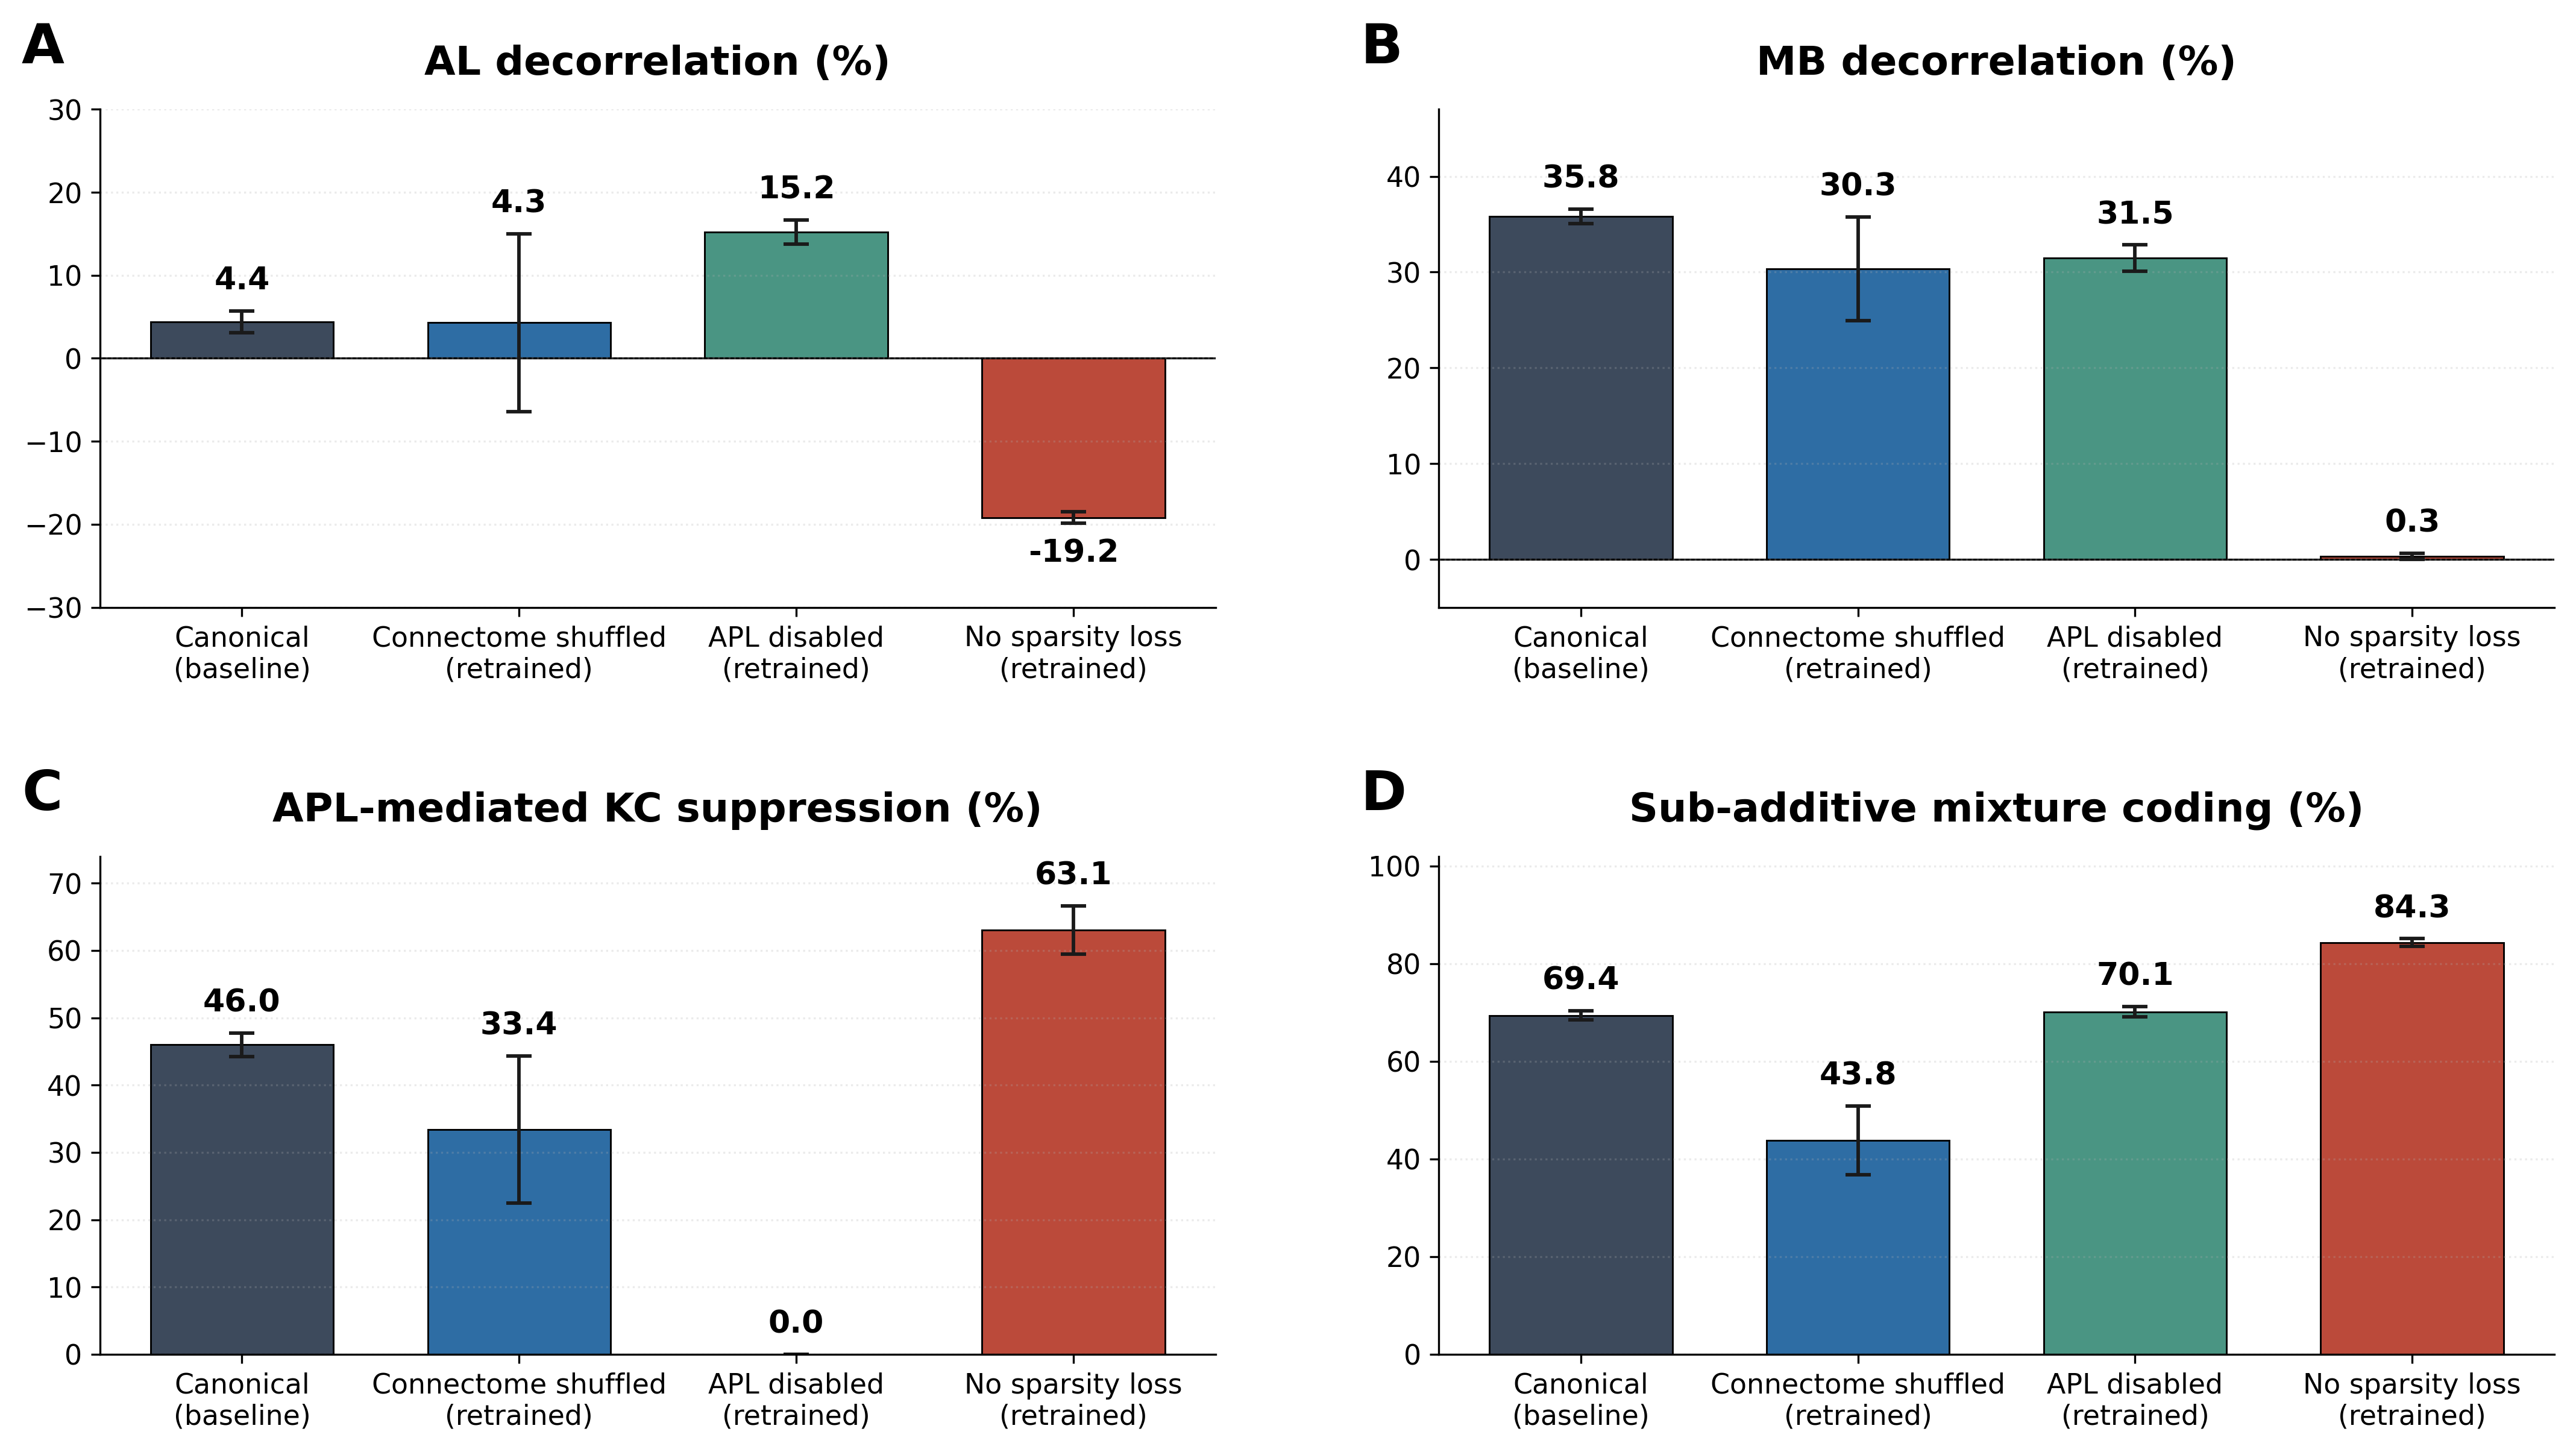

Saved 4_abl.png (A/B decorrelation, C APL-suppression, D sub-additivity).


In [38]:
# =============================================================================
# FIGURE 4 — Ablation bars (paper body) -> 4_abl.png
# A: AL decorrelation, B: MB decorrelation (from r3_results / r1_results recompute);
# C: APL-mediated KC suppression, D: sub-additive mixture coding (from r3_extra).
# Conditions: canonical / shuffled / APL-disabled / no-sparsity-loss.
# =============================================================================
assert all(v in globals() for v in ('r3_results', 'r1_results', 'r3_extra')), \
    'Run the R3 ablation, R1 energy, and F4-extra cells above first.'

def _f4_ms(rows, path, scale):
    vals = []
    for r in rows:
        v = r
        for k in path: v = v[k]
        vals.append(v * scale)
    return float(np.mean(vals)), float(np.std(vals))

_f4_conds = [
    ('Canonical\n(baseline)',            'canonical',       '#3d4a5c'),
    ('Connectome shuffled\n(retrained)', 'r3iii_shuffle',   '#2e6da4'),
    ('APL disabled\n(retrained)',        'r3ii_no_apl_fix', '#4a9583'),
    ('No sparsity loss\n(retrained)',    'ce_only',         '#bb4a3a'),
]
_decorr_src = {'canonical': 'c1', 'r3iii_shuffle': 'c1', 'r3ii_no_apl_fix': 'c1', 'ce_only': 'c7'}
def _decorr_stat(key, which):
    if _decorr_src[key] == 'c1':
        return _f4_ms(r3_results[key], ('decorrelation', which), 1)
    ag = r1_results[key][f'{which}_decorr']; return ag['mean'], ag['std']
def _extra_stat(key, which):
    v = r3_extra[key][which]
    return (float(np.mean(v)), float(np.std(v))) if v else (float('nan'), 0.0)

_f4_metrics = [   # (title, stat_fn, ylim) -- tops give headroom above the tallest bar+errorbar+label
    ('AL decorrelation (%)',            lambda k: _decorr_stat(k, 'al'),         (-30, 30)),
    ('MB decorrelation (%)',            lambda k: _decorr_stat(k, 'mb'),         (-5, 47)),
    ('APL-mediated KC suppression (%)', lambda k: _extra_stat(k, 'suppression'), (0, 74)),
    ('Sub-additive mixture coding (%)', lambda k: _extra_stat(k, 'subadd'),      (0, 102)),
]
_f4_colors = [c[2] for c in _f4_conds]; _f4_labels = [c[0] for c in _f4_conds]; _f4_letters = ['A', 'B', 'C', 'D']

fig, axes = plt.subplots(2, 2, figsize=(15.0, 8.5)); axes = axes.flatten()
for _i, (_title, _statfn, (_ymin, _ymax)) in enumerate(_f4_metrics):
    ax = axes[_i]
    _ms = [_statfn(c[1]) for c in _f4_conds]
    _means = [m for m, _ in _ms]; _stds = [s for _, s in _ms]
    _x = np.arange(len(_f4_conds))
    _bars = ax.bar(_x, _means, yerr=_stds, color=_f4_colors, edgecolor='black', linewidth=0.7,
                   width=0.66, capsize=5, error_kw={'elinewidth': 1.4, 'ecolor': '#1a1a1a', 'capthick': 1.4})
    if _ymin < 0: ax.axhline(y=0, color='black', linewidth=0.8, zorder=1)
    _rng = _ymax - _ymin; _off = _rng * 0.030
    for _bar, _mean, _std in zip(_bars, _means, _stds):
        if not np.isfinite(_mean): continue
        _h = _bar.get_height(); _small = abs(_h) < _rng * 0.10   # tiny bar -> label ABOVE so it clears the axis
        if _h >= 0 or _small:
            ax.text(_bar.get_x() + _bar.get_width() / 2, max(_h, 0) + _std + _off, f'{_mean:.1f}',
                    ha='center', va='bottom', fontsize=12.5, fontweight='bold')
        else:
            ax.text(_bar.get_x() + _bar.get_width() / 2, _h - _std - _off, f'{_mean:.1f}',
                    ha='center', va='top', fontsize=12.5, fontweight='bold')
    ax.set_title(_title, fontsize=16, fontweight='bold', pad=14)
    ax.text(-0.07, 1.07, _f4_letters[_i], transform=ax.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='left')
    ax.set_xticks(_x); ax.set_xticklabels(_f4_labels, fontsize=11)
    ax.tick_params(axis='y', labelsize=11); ax.set_ylim(_ymin, _ymax)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linestyle=':')
plt.tight_layout(); plt.subplots_adjust(hspace=0.50, wspace=0.20, top=0.93, bottom=0.12, left=0.07, right=0.975)
fig.savefig(OUTPUT_DIR / '4_abl.png', dpi=300, facecolor='white', bbox_inches='tight', pad_inches=0.12)
plt.show()
print('Saved 4_abl.png (A/B decorrelation, C APL-suppression, D sub-additivity).')


## R4: LN Picky/Broad Fan-Out Sensitivity (Reviewer 3, Point 2)

**Question:** How sensitive are biological benchmarks to the fan-out threshold that classifies LNs as Picky (excitatory) vs. Broad/Choosy (inhibitory)?

**Method:** Retrained with quantile thresholds: 0.20 (more Picky), 0.33 (default), 0.417 (Berck et al. 2016 5:7 split), 0.50 (equal split).

In [39]:
# R4: LN threshold sensitivity (5-seed aggregate) -- realized splits 9:17 / 6:20 / 12:14 / 13:13.
# PARALLEL + CACHED: each (LN-split, seed) recompute is ONE subprocess -> recompute_cache/{label}_s{seed}.json
# (skip-if-exists, deterministic eval seed 42 so the cache is exact). Self-contained: defines its own
# ablation dir, so it no longer depends on ABLATION_DIR from an earlier cell. Robustness of accuracy /
# KC-sparsity to the LN excit:inhib split.
import sys, json as _json, numpy as np
from analysis.recompute import aggregate
_CACHE = PKG_ROOT / 'results' / 'recompute_cache'
_RC = str(PKG_ROOT / 'code' / 'scripts' / 'recompute_one.py')
_ABL = PKG_ROOT / 'results' / 'ablations_r1'
# (display name, cache label, checkpoint fn)
_r4_conds = [
    ('CANONICAL 9:17 (q0.33)',    'r4_canonical', lambda s: MODEL_DIR / f'model_seed{s}.pt'),
    ('6:20 (q0.20, ~1:4)',        'r4_q0.20',     lambda s: _ABL / f'model_r4_fix_q0.20_s{s}.pt'),
    ('12:14 (q0.417, Berck 5:7)', 'r4_q0.417',    lambda s: _ABL / f'model_r4_fix_q0.417_s{s}.pt'),
    ('13:13 (q0.50, 1:1)',        'r4_q0.50',     lambda s: _ABL / f'model_r4_fix_q0.50_s{s}.pt'),
]
_cmds = []
for _name, _lab, _fn in _r4_conds:
    for _s in SEEDS:
        _out = _CACHE / f'{_lab}_s{_s}.json'
        if _fn(_s).exists() and not _out.exists():
            _cmds.append([sys.executable, _RC, '--ckpt', str(_fn(_s)), '--label', _lab,
                          '--seed', str(_s), '--output', str(_out), '--no-mancini'])
run_parallel(_cmds, desc='R4 LN-split recompute (parallel, cached)')
_r4_rows = []
for _name, _lab, _fn in _r4_conds:
    _rs = [_json.load(open(_CACHE / f'{_lab}_s{_s}.json')) for _s in SEEDS if (_CACHE / f'{_lab}_s{_s}.json').exists()]
    if _rs:
        _a = aggregate(_rs)
        _r4_rows.append((_name, _a['accuracy']['mean'], _a['accuracy']['std'],
                         _a['sparsity']['mean'], _a['al_decorr']['mean'], _a['mb_decorr']['mean'], len(_rs)))
    print(f'  {_name:<28} {len(_rs)}/5 (cached)')

print(f"\n{'LN split (excit:inhib)':<28}{'n':>3}{'acc':>9}{'KCsp%':>8}{'AL%':>7}{'MB%':>7}")
print('-' * 62)
for _name, _acc, _sd, _sp, _al, _mb, _n in _r4_rows:
    print(f"{_name:<28}{_n:>3}{_acc*100:>7.1f}% {_sp*100:>6.1f}{_al:>7.1f}{_mb:>7.1f}")
_accs = [r[1] for r in _r4_rows]
print(f"\nAccuracy across all 4 LN splits: {min(_accs)*100:.1f}-{max(_accs)*100:.1f}% "
      f"(spread {(max(_accs)-min(_accs))*100:.1f}pp);")
print("KC sparsity ~12.5% throughout -> robust. AL/MB decorrelation shifts for more-excitatory splits.")


  R4 LN-split recompute (parallel, cached): 20 runs on 11 parallel workers (12 cores detected)
  [R4 LN-split recompute (parallel, cached)] +3.0min — 11/20 done, 9 running:
    seed 43: starting...
    seed 44: starting...
    seed 45: starting...
    seed 46: starting...
    seed 42: starting...
    seed 43: starting...
    seed 44: starting...
    seed 45: starting...
  R4 LN-split recompute (parallel, cached): done (20/20 ok) in 253s
  CANONICAL 9:17 (q0.33)       5/5 (cached)
  6:20 (q0.20, ~1:4)           5/5 (cached)
  12:14 (q0.417, Berck 5:7)    5/5 (cached)
  13:13 (q0.50, 1:1)           5/5 (cached)

LN split (excit:inhib)        n      acc   KCsp%    AL%    MB%
--------------------------------------------------------------
CANONICAL 9:17 (q0.33)        5   70.3%   12.5    4.4   35.8
6:20 (q0.20, ~1:4)            5   68.9%   12.3    3.9   34.7
12:14 (q0.417, Berck 5:7)     5   70.8%   12.6   -1.5   39.5
13:13 (q0.50, 1:1)            5   70.2%   12.5   -3.3   40.3

Accuracy ac

## R5: Odor Mixture / Superposition Experiments (Reviewer 2)

**Question:** Do KC population codes produce unique, linearly separable representations for odor mixtures?

**Method:** Post-hoc analysis on trained canonical models (seeds 42-46). Mixture OR pattern = element-wise sum of component OR patterns, clamped to [0,1] (models approximately additive ORN responses at moderate concentrations; Kreher et al. 2008). 20 noisy trials per stimulus; 351 two-odor pairs (all C(27,2) combinations, excluding the sfr no-odor baseline) + 50 three-odor triplets per seed.

**Key finding:** Mixture KC codes are distinct from individual components (cosine sim ~0.79) but approximately linearly predicted from component codes (cosine sim to linear prediction ~0.94). Suppression ratio > 1 reflects APL-mediated competitive inhibition: mixture codes are sparser than the arithmetic mean of components, consistent with sparse coding via inhibitory normalisation (Honegger et al. 2011).

In [40]:
# R5: Odor-mixture geometry/decoding -- recomputed LIVE IN-CELL from canonical checkpoints.
from scripts.run_odor_mixtures import analyze_mixtures, load_canonical_model
import numpy as np
print('Recomputing mixture coding live from checkpoints (5 seeds)...')
_mres = []      # per-seed summary dicts (cosine to components, SVM separability, sub-additivity)
for s in [42, 43, 44, 45, 46]:
    _m = load_canonical_model(DATA_DIR, s, len(odor_names))
    _summ, _, _ = analyze_mixtures(_m, or_responses, odor_names, s)
    _mres.append(_summ)
_cos = np.array([r['pair_sim_to_components_mean'] for r in _mres])
_svm = np.array([r['mixture_vs_individual_svm'] for r in _mres])
print(f"  Mixture->component cosine:  {_cos.mean():.3f} +/- {_cos.std():.3f}")
print(f"  Mixture vs individual SVM:  {_svm.mean()*100:.1f}% +/- {_svm.std()*100:.1f}%")

Recomputing mixture coding live from checkpoints (5 seeds)...
  [connectome build banner suppressed]

  Getting KC codes for 28 individual odors...
  Generating 351 2-odor mixture codes...
  Generating 50 3-odor mixture codes...
  Testing linear separability...
  [connectome build banner suppressed]

  Getting KC codes for 28 individual odors...
  Generating 351 2-odor mixture codes...
  Generating 50 3-odor mixture codes...
  Testing linear separability...
  [connectome build banner suppressed]

  Getting KC codes for 28 individual odors...
  Generating 351 2-odor mixture codes...
  Generating 50 3-odor mixture codes...
  Testing linear separability...
  [connectome build banner suppressed]

  Getting KC codes for 28 individual odors...
  Generating 351 2-odor mixture codes...
  Generating 50 3-odor mixture codes...
  Testing linear separability...
  [connectome build banner suppressed]

  Getting KC codes for 28 individual odors...
  Generating 351 2-odor mixture codes...
  Generatin

In [41]:
# R5: Honegger per-KC sub-additivity — parallel (mp.Pool inside the --honegger subprocess,
# 5 seeds at once) then read the cached JSON. Skips if already computed.
import subprocess, sys, json as _json
_hjson = PKG_ROOT / 'results' / 'odor_mixtures_r5' / 'honegger_metric.json'
if not _hjson.exists():
    print('Honegger sub-additivity (5 seeds, parallel)...')
    subprocess.run([sys.executable, str(PKG_ROOT / 'code' / 'scripts' / 'run_odor_mixtures.py'),
                    '--honegger'], env=_PIN_ENV, check=True, capture_output=True)
_hres = _json.load(open(_hjson))['per_seed']
_pair = np.array([r['pair_frac_sub_additive'] for r in _hres])
_trip = np.array([r['triplet_frac_sub_additive'] for r in _hres])
print(f"Honegger sub-additive KCs: 2-odor {_pair.mean()*100:.1f}±{_pair.std()*100:.1f}% | "
      f"3-odor {_trip.mean()*100:.1f}±{_trip.std()*100:.1f}%  (Honegger 2011: 73%)")


Honegger sub-additive KCs: 2-odor 69.3±1.7% | 3-odor 72.6±1.3%  (Honegger 2011: 73%)


---
*All revision results saved to `results/energy_only_r1/`, `results/ablations_r1/`, `results/posthoc_ablations/` and `results/odor_mixtures_r5/`. Code: `run_training.py (energy variants via flags)`, `run_ablation.py`, `run_ablation.py posthoc`, `run_odor_mixtures.py`.*

In [42]:
# R6: Task Complexity -- KC threshold scaling vs odor count (7/14/28/56).
# Reuses _s4_scaling computed once for Figure S4 (parameter-only kc_upper_bound_fraction over the
# same checkpoints) so the bound fractions are not computed twice.
import numpy as np
assert '_s4_scaling' in globals(), 'Run the Figure S4 cell first (it computes _s4_scaling).'
r6_scaling = dict(_s4_scaling)
print('R6: Task Complexity -- KC at upper bound (-30 mV)')
print('=' * 60)
for n_od in [7, 14, 28, 56]:
    mean, std = r6_scaling[n_od]
    print(f"  n={n_od:2d} odors: KC at upper bound = {mean*100:5.1f}% +/- {std*100:.1f}%")
print("\n  -> KC threshold pinning scales with task difficulty (sparsity mechanism).")

R6: Task Complexity -- KC at upper bound (-30 mV)
  n= 7 odors: KC at upper bound =  11.9% +/- 4.3%
  n=14 odors: KC at upper bound =  35.3% +/- 0.9%
  n=28 odors: KC at upper bound =  46.7% +/- 0.8%
  n=56 odors: KC at upper bound =  55.8% +/- 1.6%

  -> KC threshold pinning scales with task difficulty (sparsity mechanism).


In [43]:
# ALL REVISION VALUES CITED IN ccn_proceedings.tex (Sections 3.5-3.9) -- FULLY IN-CELL.
# References the live-recomputed results from the cells above (mixtures/honegger/teacher-student/
# ablations/energy) and recomputes parameter boundaries directly from the checkpoints. No JSON loads.
import numpy as np, torch
print('=' * 64); print('Revision Additional Paper Values (computed live)'); print('=' * 64)

print('\n--- Odor Mixtures (3.5) ---')
_cos = np.array([r['pair_sim_to_components_mean'] for r in _mres])
_svm = np.array([r['mixture_vs_individual_svm'] for r in _mres])
_p2 = np.array([r['pair_frac_sub_additive'] for r in _hres])
_p3 = np.array([r['triplet_frac_sub_additive'] for r in _hres])
print(f'  Mix->component cosine:   {_cos.mean():.3f} +/- {_cos.std():.3f}')
print(f'  Mix vs individual SVM:   {_svm.mean()*100:.1f}%')
print(f'  Honegger 2-odor sub-add: {_p2.mean()*100:.1f}%  (Honegger 2011: 73%)')
print(f'  Honegger 3-odor sub-add: {_p3.mean()*100:.1f}%')

print('\n--- Connectome dominates / Teacher-Student (3.6) ---')
_pt = {'or_gains':21,'kc_threshold':144,'decoder_weight':4032,'decoder_bias':28}
_ps = {'or_gains':21,'kc_v_th':144,'ln_v_th':108,'orn_v_th':21,'pn_v_th':72,'decoder_weight':4032,'decoder_bias':28}
_wt = sum(tt[k]['mean_correlation']*v for k,v in _pt.items())/sum(_pt.values())
_ws = sum(ss[k]['mean_correlation']*v for k,v in _ps.items())/sum(_ps.values())
print(f'  Teacher r {_wt:.3f} -> Student r {_ws:.3f}  (delta +{_ws-_wt:.3f})')
print(f"  KC thresholds: {tt['kc_threshold']['mean_correlation']:.3f} -> {ss['kc_v_th']['mean_correlation']:.3f}")
print(f"  Decoder weights: {tt['decoder_weight']['mean_correlation']:.3f} -> {ss['decoder_weight']['mean_correlation']:.3f}")
_scv = [c5['student_student']['scalar_params'][q]['cv'] for q in ['apl_gain','g_gap_ln','g_gap_pn','g_gap_eln_pn','g_soma','orn_pn_strength','ln_pn_strength','ln_pn_excit_strength','kc_kc_aa_strength','pn_kc_strength','tau_apl']]
_tcv = [c5['teacher_teacher']['scalar_params'][q]['cv'] for q in ['orn_pn_strength','ln_pn_strength','apl_gain']]
_tag = c5['teacher_teacher']['scalar_params']['apl_gain']['cv']*100
_sag = c5['student_student']['scalar_params']['apl_gain']['cv']*100
print(f'  Scalar CV (physical units): teacher mean {np.mean(_tcv)*100:.1f}% -> student mean {np.mean(_scv)*100:.1f}% (range {min(_scv)*100:.1f}-{max(_scv)*100:.1f}%); apl_gain {_tag:.1f}%->{_sag:.1f}%')

print('\n--- Parameter boundaries (3.7, recomputed from checkpoints) ---')
_ku, _ll, _pi = [], [], []
for s in [42, 43, 44, 45, 46]:
    sd = torch.load(MODEL_DIR / f'model_seed{s}.pt', map_location='cpu', weights_only=False)
    kc = sd['kc_layer.kc_neurons.v_th'].numpy()*1e3; ln = sd['antennal_lobe.ln_neurons.v_th'].numpy()*1e3; pn = sd['antennal_lobe.pn_neurons.v_th'].numpy()*1e3
    _ku.append((kc>=-30.5).mean()); _ll.append((ln<=-54.5).mean()); _pi.append(((pn>-54.5)&(pn<-30.5)).mean())
print(f'  KC at upper bound: {np.mean(_ku)*100:.1f}% | LN at lower: {np.mean(_ll)*100:.1f}% | PN interior: {np.mean(_pi)*100:.1f}%')

print('\n--- Ablations (3.8) ---')
def _m(rows, k):
    return np.mean([r['accuracy'] if k=='acc' else (r['per_type_sparsity']['kc'] if k=='kc' else r['decorrelation'][k]) for r in rows])
print(f"  No gap: retrained {_m(r3_results['r3i_no_gap'],'acc')*100:.1f}%, post-hoc {_m(r3_ph_gap,'acc')*100:.1f}% (dispensable both)")
print(f"  No APL retrained: {_m(r3_results['r3ii_no_apl_fix'],'acc')*100:.1f}%  AL {_m(r3_results['r3ii_no_apl_fix'],'al'):.1f}% MB {_m(r3_results['r3ii_no_apl_fix'],'mb'):.1f}%")
print(f"  No APL post-hoc KC sparsity: {_m(r3_ph_apl,'kc')*100:.1f}% (~doubled)")
print(f"  Shuffled: {_m(r3_results['r3iii_shuffle'],'acc')*100:.1f}%  AL {_m(r3_results['r3iii_shuffle'],'al'):.1f}%")

print('\n--- Sparsity constraint (3.9) ---')
print(f"  CE only (no sparsity loss) KC activity: {r1_results['ce_only']['sparsity']['mean']*100:.1f}%")
print(f"  All-neuron penalty KC: {r1_results['energy_50']['sparsity']['mean']*100:.1f}% | KC-specific: {r1_results['kc_energy_50']['sparsity']['mean']*100:.1f}%")
print('\n  Kreher RI range: -0.40 to 0.74 (cited 3.1)')

Revision Additional Paper Values (computed live)

--- Odor Mixtures (3.5) ---
  Mix->component cosine:   0.805 +/- 0.004
  Mix vs individual SVM:   74.2%
  Honegger 2-odor sub-add: 69.3%  (Honegger 2011: 73%)
  Honegger 3-odor sub-add: 72.6%

--- Connectome dominates / Teacher-Student (3.6) ---
  Teacher r 0.781 -> Student r 0.909  (delta +0.128)
  KC thresholds: 0.528 -> 0.953
  Decoder weights: 0.788 -> 0.903
  Scalar CV (physical units): teacher mean 5.4% -> student mean 1.8% (range 0.3-3.8%); apl_gain 5.4%->3.8%

--- Parameter boundaries (3.7, recomputed from checkpoints) ---
  KC at upper bound: 46.7% | LN at lower: 29.3% | PN interior: 83.6%

--- Ablations (3.8) ---
  No gap: retrained 71.2%, post-hoc 70.2% (dispensable both)
  No APL retrained: 65.3%  AL 15.2% MB 31.5%
  No APL post-hoc KC sparsity: 29.4% (~doubled)
  Shuffled: 64.7%  AL 4.3%

--- Sparsity constraint (3.9) ---
  CE only (no sparsity loss) KC activity: 79.7%
  All-neuron penalty KC: 30.3% | KC-specific: 14.1%

  

---
## STD Ablation — Short-Term Synaptic Depression

**Question:** Is short-term depression (STD, Tsodyks-Markram model) necessary for the circuit's computational properties?

**Two conditions (seeds 42-46):**
- **no_std_train** — trained from scratch with STD disabled at every timestep; tests whether STD is needed *during learning*.
- **posthoc_std_off** — canonical trained weights, STD disabled at eval time only; tests whether STD matters for *inference/read-out*.

**STD model:** Tsodyks-Markram — vesicle pool *x* recovers with τ_rec (learnable, init 200 ms), depletes by *U × spikes* per timestep (U learnable, init 0.30).
Applied to all chemical synapses in the circuit.

Results directory: `results/std_ablation/`

### Setup: load STD ablation results

In [44]:
# STD ablation: recompute from checkpoints — PARALLEL + CACHED. STD disabled via --disable-std
# (no_std_train: trained-without-STD checkpoint; posthoc: canonical + STD off at eval). The
# STD-removed rows also run the concentration sweep (--with-concentration) to cache the PN/KC
# dynamic ranges; each (cond, seed) is ONE subprocess -> recompute_cache/{label}_s{seed}.json
# (skip-if-exists, deterministic eval seed 42).
import sys, json as _json, numpy as np
_CACHE = PKG_ROOT / 'results' / 'recompute_cache'
_RC = str(PKG_ROOT / 'code' / 'scripts' / 'recompute_one.py')
_STDD = PKG_ROOT / 'results' / 'std_ablation'
_std_conds = [
    ('canonical (STD on)', 'std_canonical', lambda s: MODEL_DIR / f'model_seed{s}.pt',            []),
    ('no-STD training',    'std_no_train',  lambda s: _STDD / f'no_std_train/model_seed{s}.pt',   ['--disable-std', '--with-concentration']),
    ('post-hoc STD off',   'std_posthoc',   lambda s: MODEL_DIR / f'model_seed{s}.pt',            ['--disable-std', '--with-concentration']),
]
_cmds = []
for _name, _lab, _fn, _flags in _std_conds:
    for _s in SEEDS:
        _out = _CACHE / f'{_lab}_s{_s}.json'
        if _fn(_s).exists() and not _out.exists():
            _cmds.append([sys.executable, _RC, '--ckpt', str(_fn(_s)), '--label', _lab,
                          '--seed', str(_s), '--output', str(_out)] + _flags)
run_parallel(_cmds, desc='STD ablation recompute (parallel, cached)')
def _std_load(lab):
    rows = []
    for s in SEEDS:
        p = _CACHE / f'{lab}_s{s}.json'
        if not p.exists():
            continue
        m = _json.load(open(p))
        row = {'accuracy': m['accuracy'], 'sparsity': m['sparsity'], 'mancini': m.get('mancini', float('nan')),
               'per_pair_decorrelation': {'mb_decorr_pct': m['mb_decorr'], 'al_decorr_pct': m['al_decorr']}}
        if m.get('pn_range') is not None:
            row['pn_range'] = m['pn_range']; row['kc_range'] = m['kc_range']
        rows.append(row)
    return rows
canonical    = _std_load('std_canonical')
std_no_train = _std_load('std_no_train')
std_posthoc  = _std_load('std_posthoc')
for _n, _r in [('canonical (STD on)', canonical), ('no-STD training', std_no_train), ('post-hoc STD off', std_posthoc)]:
    print(f'  {_n:<22} n={len(_r)}, acc={np.mean([x["accuracy"] for x in _r]):.1%}' if _r else f'  {_n:<22} 0/5 (cached)')


  STD ablation recompute (parallel, cached): 15 runs on 11 parallel workers (12 cores detected)
  [STD ablation recompute (parallel, cached)] +3.0min — 5/15 done, 10 running:
    seed 42: starting...
    seed 43: starting...
    seed 44: starting...
    seed 45: starting...
    seed 46: starting...
    seed 42: starting...
    seed 43: starting...
    seed 44: starting...
  [STD ablation recompute (parallel, cached)] +6.0min — 5/15 done, 10 running:
    seed 42: starting...
    seed 43: starting...
    seed 44: starting...
    seed 45: starting...
    seed 46: starting...
    seed 42: starting...
    seed 43: starting...
    seed 44: starting...
  [STD ablation recompute (parallel, cached)] +9.0min — 5/15 done, 10 running:
    seed 42: starting...
    seed 43: starting...
    seed 44: starting...
    seed 45: starting...
    seed 46: starting...
    seed 42: starting...
    seed 43: starting...
    seed 44: starting...
  STD ablation recompute (parallel, cached): done (15/15 ok) in 673

### Metrics comparison table

In [45]:
# 3-condition STD comparison table — computed from loaded results, NO hardcoded fallback.
# Canonical | No-STD training | Post-hoc STD removal
def condition_summary(results, name):
    assert results, f"No results loaded for {name} -- run scripts/run_ablation.py std first"
    accs = [r['accuracy'] for r in results]
    sps  = [r['sparsity'] for r in results]
    als  = [r['per_pair_decorrelation']['al_decorr_pct'] for r in results]
    mbs  = [r['per_pair_decorrelation']['mb_decorr_pct'] for r in results]
    mns  = [r['mancini'] for r in results]
    return (np.mean(accs), np.std(accs), np.mean(sps), np.std(sps), np.mean(mbs), np.std(mbs),
            np.mean(als), np.std(als), np.mean(mns), np.std(mns))

cond_data = {
    'Canonical (with STD)':  condition_summary(canonical, 'canonical'),
    'No-STD training':       condition_summary(std_no_train, 'no_std_train'),
    'Post-hoc STD removal':  condition_summary(std_posthoc, 'posthoc_std_off'),
}

print(f"\n{'Condition':<26} {'Acc (%)':>9} {'KC Sp (%)':>11} {'AL Decorr (%)':>15} {'MB Decorr (%)':>15} {'Manc':>9}")
print('-' * 90)
for cname, (am, as_, sm, ss, mm, ms, alm, als, mnm, mns) in cond_data.items():
    acc_str = f"{am*100:.1f}" + (f" +/-{as_*100:.1f}" if as_ > 0 else "")
    sp_str  = f"{sm*100:.1f}" + (f" +/-{ss*100:.1f}" if ss > 0 else "")
    al_str  = f"{alm:.1f}"    + (f" +/-{als:.1f}"     if als > 0 else "")
    mb_str  = f"{mm:.1f}"     + (f" +/-{ms:.1f}"      if ms > 0 else "")
    mn_str  = f"{mnm:.2f}"    + (f" +/-{mns:.2f}"     if mns > 0 else "")
    print(f"{cname:<26} {acc_str:>9} {sp_str:>11} {al_str:>15} {mb_str:>15} {mn_str:>9}")
print('-' * 90)

cn, nt, ph = cond_data['Canonical (with STD)'], cond_data['No-STD training'], cond_data['Post-hoc STD removal']
print(f"\nKey finding: training WITHOUT STD ~ canonical accuracy ({nt[0]*100:.1f}% vs {cn[0]*100:.1f}%)")
print(f"but sparser KC activity ({nt[2]*100:.1f}% vs {cn[2]*100:.1f}%).")
print(f"Post-hoc STD removal devastating ({ph[0]*100:.1f}%) -> STD's role baked into learned weights.")


Condition                    Acc (%)   KC Sp (%)   AL Decorr (%)   MB Decorr (%)      Manc
------------------------------------------------------------------------------------------
Canonical (with STD)       70.3 +/-1.1 12.5 +/-0.1      4.4 +/-1.3     35.8 +/-0.8 1.85 +/-0.05
No-STD training            70.4 +/-0.4 10.3 +/-0.2      1.8 +/-0.3     42.1 +/-0.6 1.73 +/-0.05
Post-hoc STD removal       50.4 +/-0.8 22.2 +/-0.4      6.7 +/-1.4     39.5 +/-1.1 1.87 +/-0.06
------------------------------------------------------------------------------------------

Key finding: training WITHOUT STD ~ canonical accuracy (70.4% vs 70.3%)
but sparser KC activity (10.3% vs 12.5%).
Post-hoc STD removal devastating (50.4%) -> STD's role baked into learned weights.


### Summary statistics for manuscript

In [46]:
# Delta vs canonical for each STD condition -- from the LIVE recompute above
# (canonical/std_no_train/std_posthoc, seed 42; no pre-saved JSON). Inline mean/std over seeds.
import numpy as np
def _ms(results, key):
    v = np.array([r[key] for r in results], dtype=float); return v.mean(), v.std()
def _pp(results, key):
    v = np.array([r['per_pair_decorrelation'][key] for r in results], dtype=float); return v.mean(), v.std()

if canonical:
    c_acc_m, c_acc_s = _ms(canonical, 'accuracy')
    c_sp_m,  c_sp_s  = _ms(canonical, 'sparsity')
    c_al_m,  c_al_s  = _pp(canonical, 'al_decorr_pct')
    c_mb_m,  c_mb_s  = _pp(canonical, 'mb_decorr_pct')
    print("Canonical (with STD):")
    print(f"  Acc = {c_acc_m:.1%} +/- {c_acc_s*100:.1f}%")
    print(f"  KC sparsity = {c_sp_m:.1%} +/- {c_sp_s*100:.1f}%")
    print(f"  AL decorr = {c_al_m:.1f} +/- {c_al_s:.1f}%")
    print(f"  MB decorr = {c_mb_m:.1f} +/- {c_mb_s:.1f}%")
    print()

for cond_name, results in [('no_std_train', std_no_train), ('posthoc_std_off', std_posthoc)]:
    if not results:
        print(f"{cond_name}: no data"); continue
    acc_m, acc_s = _ms(results, 'accuracy')
    sp_m,  sp_s  = _ms(results, 'sparsity')
    al_m,  al_s  = _pp(results, 'al_decorr_pct')
    mb_m,  mb_s  = _pp(results, 'mb_decorr_pct')
    print(f"{cond_name}:")
    print(f"  Acc = {acc_m:.1%} +/- {acc_s*100:.1f}%" + (f"  (delta = {(acc_m-c_acc_m)*100:+.1f} pp)" if canonical else ""))
    print(f"  KC sparsity = {sp_m:.1%} +/- {sp_s*100:.1f}%" + (f"  (delta = {(sp_m-c_sp_m)*100:+.1f} pp)" if canonical else ""))
    print(f"  AL decorr = {al_m:.1f} +/- {al_s:.1f}%" + (f"  (delta = {al_m-c_al_m:+.1f}%)" if canonical else ""))
    print(f"  MB decorr = {mb_m:.1f} +/- {mb_s:.1f}%" + (f"  (delta = {mb_m-c_mb_m:+.1f}%)" if canonical else ""))
    print()

# Gain control: concentration dynamic ranges (paper: STD removed eliminates gain control --
# PN ~2.8x / KC ~2.8x vs canonical ~1.24x / ~1.14x). Canonical ranges come from the main
# concentration cell (pn_ranges/kc_ranges); STD-removed ranges from the with_conc recompute above.
if 'pn_ranges' in globals() and std_no_train and 'pn_range' in std_no_train[0]:
    _nt_pn = np.mean([r['pn_range'] for r in std_no_train]); _nt_kc = np.mean([r['kc_range'] for r in std_no_train])
    print("Gain control (concentration dynamic range, high/low):")
    print(f"  Canonical (with STD):  PN {np.mean(pn_ranges):.2f}x, KC {np.mean(kc_ranges):.2f}x")
    print(f"  No-STD (trained):      PN {_nt_pn:.2f}x, KC {_nt_kc:.2f}x  -> gain control eliminated")
    if std_posthoc and 'pn_range' in std_posthoc[0]:
        _ph_pn = np.mean([r['pn_range'] for r in std_posthoc]); _ph_kc = np.mean([r['kc_range'] for r in std_posthoc])
        print(f"  Post-hoc STD off:      PN {_ph_pn:.2f}x, KC {_ph_kc:.2f}x")
    print()

print("Interpretation key:")
print("  no_std_train    -> does STD need to be PRESENT DURING TRAINING?")
print("  posthoc_std_off -> does STD affect INFERENCE on a trained model?")
print("  Large drop in posthoc -> STD's role baked into learned weights.")

Canonical (with STD):
  Acc = 70.3% +/- 1.1%
  KC sparsity = 12.5% +/- 0.1%
  AL decorr = 4.4 +/- 1.3%
  MB decorr = 35.8 +/- 0.8%

no_std_train:
  Acc = 70.4% +/- 0.4%  (delta = +0.0 pp)
  KC sparsity = 10.3% +/- 0.2%  (delta = -2.2 pp)
  AL decorr = 1.8 +/- 0.3%  (delta = -2.6%)
  MB decorr = 42.1 +/- 0.6%  (delta = +6.3%)

posthoc_std_off:
  Acc = 50.4% +/- 0.8%  (delta = -20.0 pp)
  KC sparsity = 22.2% +/- 0.4%  (delta = +9.7 pp)
  AL decorr = 6.7 +/- 1.4%  (delta = +2.3%)
  MB decorr = 39.5 +/- 1.1%  (delta = +3.7%)

Interpretation key:
  no_std_train    -> does STD need to be PRESENT DURING TRAINING?
  posthoc_std_off -> does STD affect INFERENCE on a trained model?
  Large drop in posthoc -> STD's role baked into learned weights.


In [47]:
# =============================================================================
# SAVE ALL NOTEBOOK VALUES  ->  figures/paper_values.json
# Persists every paper-cited number this notebook computes (main text + all
# revision sections) into ONE JSON, so the full numerical record is saved
# (figures are saved to OUTPUT_DIR; per-experiment results + trained models live
# under results/<subdir>/). Robust to partial runs: any section whose variables
# are missing is skipped and listed under "_skipped".
# =============================================================================
import json, numpy as np, torch

def _g(fn):
    try:
        return fn()
    except Exception as e:
        return {'_error': str(e)}

PV = {'_meta': {'seeds': SEEDS, 'n_steps': N_STEPS, 'eval_seed': 42, 'noise_std': NOISE_STD,
                'note': 'Recomputed live from checkpoints via analysis/recompute.py (deterministic, eval seed 42).'}}

# ---- Main text (3.1-3.4, 3.6-3.7) -- use agg/per_seed_metrics (NOT accs/sps, which
#      a later STD cell reuses for its own table). ----
PV['main'] = _g(lambda: {
    'teacher_accuracy_mean': float(np.mean(teacher_accs)),
    'test_accuracy':    {'mean': agg['accuracy']['mean'], 'std': agg['accuracy']['std'],
                         'per_seed': [float(r['accuracy']) for r in per_seed_metrics]},
    'centroid_accuracy':{'mean': agg['centroid']['mean'], 'std': agg['centroid']['std']},
    'kc_sparsity':      {'mean': agg['sparsity']['mean'], 'std': agg['sparsity']['std'],
                         'per_seed': [float(r['sparsity']) for r in per_seed_metrics]},
    'al_decorr_mean': agg['al_decorr']['mean'], 'mb_decorr_mean': agg['mb_decorr']['mean'],
    'total_decorr_mean': agg['total_decorr']['mean'],
    'mancini_ratio': {'mean': agg['mancini']['mean'], 'std': agg['mancini']['std']},
    'kc_suppression_pct': float(kc_suppression),
    'pn_dynamic_range': {'mean': float(np.mean(pn_ranges)), 'std': float(np.std(pn_ranges))},
    'or_input_range_mean': float(np.mean(or_ranges)),
    'kc_dynamic_range_mean': float(np.mean(kc_ranges)),
    'accuracy_at_c0_3': float(np.mean(acc_03)), 'accuracy_at_c5_0': float(np.mean(acc_50)),
    'kc_pattern_consistency': float(kc_consistency),
    'g_soma_nS': {'mean': float(np.mean(g_soma_vals)), 'std': float(np.std(g_soma_vals))},
    'gap_junctions_nS': {'ln_ln': float(np.mean([g['ln_ln'] for g in all_gap_info]) * 1e9),
                         'pn_pn': float(np.mean([g['pn_pn'] for g in all_gap_info]) * 1e9),
                         'eln_pn': float(np.mean([g['eln_pn'] for g in all_gap_info]) * 1e9)},
    'or_pairs_cosine_gt_0_90': int(_n_or_high),
})

# ---- Odor mixtures (3.5) ----
PV['mixtures'] = _g(lambda: {
    'mix_to_component_cosine': {'mean': float(np.mean([r['pair_sim_to_components_mean'] for r in _mres])),
                                'std': float(np.std([r['pair_sim_to_components_mean'] for r in _mres]))},
    'mix_vs_individual_svm': float(np.mean([r['mixture_vs_individual_svm'] for r in _mres])),
    'honegger_2odor_subadditive': float(np.mean([r['pair_frac_sub_additive'] for r in _hres])),
    'honegger_3odor_subadditive': float(np.mean([r['triplet_frac_sub_additive'] for r in _hres])),
})

# ---- Teacher/student consistency (3.6) ----
PV['teacher_student'] = _g(lambda: {
    'weighted_r_teacher': float(sum(tt[k]['mean_correlation'] * v for k, v in
                            {'or_gains': 21, 'kc_threshold': 144, 'decoder_weight': 4032, 'decoder_bias': 28}.items()) / (21 + 144 + 4032 + 28)),
    'weighted_r_student': float(sum(ss[k]['mean_correlation'] * v for k, v in
                            {'or_gains': 21, 'kc_v_th': 144, 'ln_v_th': 108, 'orn_v_th': 21, 'pn_v_th': 72, 'decoder_weight': 4032, 'decoder_bias': 28}.items()) / (21 + 144 + 108 + 21 + 72 + 4032 + 28)),
    'kc_threshold_r': {'teacher': float(tt['kc_threshold']['mean_correlation']), 'student': float(ss['kc_v_th']['mean_correlation'])},
    'decoder_weight_r': {'teacher': float(tt['decoder_weight']['mean_correlation']), 'student': float(ss['decoder_weight']['mean_correlation'])},
    'scalar_cv_physical_pct': {
        'teacher_mean': float(np.mean([c5['teacher_teacher']['scalar_params'][q]['cv'] for q in ['orn_pn_strength', 'ln_pn_strength', 'apl_gain']]) * 100),
        'student_mean': float(np.mean([c5['student_student']['scalar_params'][q]['cv'] for q in ['apl_gain', 'g_gap_ln', 'g_gap_pn', 'g_gap_eln_pn', 'g_soma', 'orn_pn_strength', 'ln_pn_strength', 'ln_pn_excit_strength', 'kc_kc_aa_strength', 'pn_kc_strength', 'tau_apl']]) * 100),
        'apl_gain': {'teacher': float(c5['teacher_teacher']['scalar_params']['apl_gain']['cv'] * 100),
                     'student': float(c5['student_student']['scalar_params']['apl_gain']['cv'] * 100)},
    },
})

# ---- Ablations (3.8) incl. the (fair, retrained) SHUFFLE ----
def _agg_r3(rows):
    return {'accuracy': float(np.mean([r['accuracy'] for r in rows])),
            'accuracy_std': float(np.std([r['accuracy'] for r in rows])),
            'kc_sparsity': float(np.mean([r['per_type_sparsity']['kc'] for r in rows])),
            'al_decorr': float(np.mean([r['decorrelation']['al'] for r in rows])),
            'mb_decorr': float(np.mean([r['decorrelation']['mb'] for r in rows])),
            'per_seed': [{'seed': r['seed'], 'accuracy': r['accuracy'], 'kc': r['per_type_sparsity']['kc'],
                          'al': r['decorrelation']['al'], 'mb': r['decorrelation']['mb']} for r in rows]}
PV['ablations'] = _g(lambda: {
    'canonical':          _agg_r3(r3_results['canonical']),
    'no_gap_retrained':   _agg_r3(r3_results['r3i_no_gap']),
    'no_apl_retrained':   _agg_r3(r3_results['r3ii_no_apl_fix']),
    'shuffled_retrained': _agg_r3(r3_results['r3iii_shuffle']),
    'no_gap_posthoc':     _agg_r3(r3_ph_gap),
    'no_apl_posthoc':     _agg_r3(r3_ph_apl),
})

# ---- Energy / sparsity-loss forms (3.9) ----
PV['energy'] = _g(lambda: {k: {'kc_sparsity_mean': r1_results[k]['sparsity']['mean']} for k in r1_results})

# ---- Task-complexity KC-threshold scaling (Fig S4) ----
PV['task_complexity_kc_upperbound'] = _g(lambda: {str(n): {'mean': float(r6_scaling[n][0]), 'std': float(r6_scaling[n][1])} for n in r6_scaling})

# ---- STD ablation ----
def _agg_std(rows):
    out = {'accuracy': float(np.mean([r['accuracy'] for r in rows])), 'kc_sparsity': float(np.mean([r['sparsity'] for r in rows]))}
    if rows and 'pn_range' in rows[0]:
        out['pn_range'] = float(np.mean([r['pn_range'] for r in rows]))
        out['kc_range'] = float(np.mean([r['kc_range'] for r in rows]))
    return out
PV['std_ablation'] = _g(lambda: {'canonical': _agg_std(canonical), 'no_std_train': _agg_std(std_no_train), 'posthoc_std_off': _agg_std(std_posthoc)})

# ---- Parameter boundaries (3.7) ----
def _param_bounds():
    # §3.7 threshold boundaries, recomputed from checkpoints (matches the live-values cell):
    # KC pinned at upper clamp, LN at lower, PN interior.
    ku, ll, pi = [], [], []
    for s in SEEDS:
        sd = torch.load(MODEL_DIR / f'model_seed{s}.pt', map_location='cpu', weights_only=False)
        kc = sd['kc_layer.kc_neurons.v_th'].numpy() * 1e3
        ln = sd['antennal_lobe.ln_neurons.v_th'].numpy() * 1e3
        pn = sd['antennal_lobe.pn_neurons.v_th'].numpy() * 1e3
        ku.append((kc >= -30.5).mean()); ll.append((ln <= -54.5).mean()); pi.append(((pn > -54.5) & (pn < -30.5)).mean())
    return {'kc_at_upper_bound_pct': float(np.mean(ku) * 100),
            'ln_at_lower_bound_pct': float(np.mean(ll) * 100),
            'pn_interior_pct': float(np.mean(pi) * 100)}
PV['parameter_boundaries'] = _g(_param_bounds)

# ---- LN threshold sensitivity (R4) ----
PV['ln_threshold_sensitivity'] = _g(lambda: [
    {'split': r[0], 'accuracy_mean': float(r[1]), 'accuracy_std': float(r[2]),
     'kc_sparsity_mean': float(r[3]), 'al_decorr_mean': float(r[4]), 'mb_decorr_mean': float(r[5]), 'n_seeds': r[6]}
    for r in _r4_rows])

out_path = OUTPUT_DIR / 'paper_values.json'
with open(out_path, 'w') as f:
    json.dump(PV, f, indent=2, default=float)
_skipped = [k for k, v in PV.items() if isinstance(v, dict) and v.get('_error')]
print('Saved ALL notebook paper values ->', out_path)
print('  Figures      ->', OUTPUT_DIR, '(*.png)')
print('  Values       ->', out_path)
print('  Results/JSON ->', PKG_ROOT / 'results', '(per-experiment subfolders)')
print('  Models (.pt) ->', PKG_ROOT / 'results', '(canonical + ablation/variant subfolders)')
if _skipped:
    print('  NOTE: sections skipped (cells not run this session):', _skipped)


Saved ALL notebook paper values -> figures/paper_values.json
  Figures      -> figures (*.png)
  Values       -> figures/paper_values.json
  Results/JSON -> results (per-experiment subfolders)
  Models (.pt) -> results (canonical + ablation/variant subfolders)
  NOTE: sections skipped (cells not run this session): ['main', 'teacher_student']
